# Notebook 4: MLP Deep Learning Model
This notebook implements the core deep learning model — a **Multi-Layer Perceptron (MLP)** — to predict road collision injury severity in Greater London. The model uses a triple-layered imbalance handling strategy:

1. **WeightedRandomSampler** — ensures Fatal crashes appear in every training batch
2. **Class Weights** — penalises Fatal misclassifications 160x harder than Slight
3. **Focal Loss** — dynamically concentrates learning effort on hard-to-classify crashes

The model must beat the Random Forest baseline: **Macro F1 > 0.31, Fatal Recall > 0%, MCC > 0.028**.

## Step 1: Load Data & Build PyTorch DataLoaders
We load the preprocessed artefacts from Notebook 2 and wrap them in PyTorch's `TensorDataset` (faster than a custom class for in-memory tabular data). The training DataLoader uses `WeightedRandomSampler` to oversample Fatal crashes — ensuring every batch of 64 contains minority class representation.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import joblib
import matplotlib.pyplot as plt
import warnings
import os
import copy

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device selection
device = torch.device('mps' if torch.backends.mps.is_available() else 
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load preprocessed artefacts
data = joblib.load('../outputs/models/preprocessed_data.joblib')
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
class_weights = data['class_weights']
feature_names = data['feature_names']

print(f"Train: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Val:   {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Class weights: Fatal={class_weights[0]:.2f}, Serious={class_weights[1]:.2f}, Slight={class_weights[2]:.2f}")

# --- Convert to PyTorch Tensors ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# --- TensorDatasets ---
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

# --- WeightedRandomSampler for training ---
# Assign each sample a weight based on its class (inverse frequency)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float32)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # sample same number per epoch
    replacement=True  # required for oversampling minority classes
)

# --- DataLoaders ---
BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders created (batch_size={BATCH_SIZE}):")
print(f"  Train: {len(train_loader)} batches with WeightedRandomSampler")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

# --- Verify sampler is working ---
# Check class distribution in a few training batches
class_counts = torch.zeros(3)
for batch_X, batch_y in train_loader:
    for c in range(3):
        class_counts[c] += (batch_y == c).sum().item()
    
class_pcts = class_counts / class_counts.sum() * 100
labels = ['Fatal', 'Serious', 'Slight']
print(f"\nSampler verification (effective class distribution across 1 epoch):")
for i, (name, pct) in enumerate(zip(labels, class_pcts)):
    print(f"  {name:>7s}: {pct:.1f}%  (original: {(y_train == i).sum() / len(y_train) * 100:.1f}%)")

Using device: mps


Train: 14,676 samples, 21 features
Val:   3,145 | Test: 3,146
Class weights: Fatal=64.37, Serious=2.00, Slight=0.40

DataLoaders created (batch_size=64):
  Train: 230 batches with WeightedRandomSampler
  Val:   50 batches
  Test:  50 batches

Sampler verification (effective class distribution across 1 epoch):
    Fatal: 33.2%  (original: 0.5%)
  Serious: 33.6%  (original: 16.7%)
   Slight: 33.1%  (original: 82.8%)


## Step 2: MLP Architecture
A 3-layer "funnel" MLP: 21 input features → 128 → 64 → 32 → 3 output classes. Each hidden layer follows the research-backed block pattern: `Linear → BatchNorm → ReLU → Dropout(0.3)`.

- **BatchNorm:** Stabilises the data flowing between layers so each layer receives numbers in a consistent range, even as the model's weights update during training.
- **ReLU:** Introduces non-linearity — without it, stacking layers is mathematically identical to a single layer.  
- **Dropout(0.3):** Randomly disables 30% of neurons each training step, forcing the model to build redundant knowledge and preventing overfitting on 14,676 samples.

In [2]:
class CollisionMLP(nn.Module):
    """
    Multi-Layer Perceptron for collision severity prediction.
    Architecture: 21 → 128 → 64 → 32 → 3 (funnel design)
    Each hidden block: Linear → BatchNorm → ReLU → Dropout
    """
    def __init__(self, input_dim=21, num_classes=3, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            # Layer 1: 21 → 128 (discover patterns from raw features)
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Layer 2: 128 → 64 (refine and compress patterns)
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Layer 3: 64 → 32 (distill into severity signals)
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            # Output: 32 → 3 (Fatal, Serious, Slight probabilities)
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialise the model
model = CollisionMLP(input_dim=X_train.shape[1], num_classes=3, dropout=0.3)
model = model.to(device)

# Display architecture summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("CollisionMLP Architecture:")
print(model)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Quick forward pass test
with torch.no_grad():
    sample_batch = X_train_t[:5].to(device)
    sample_output = model(sample_batch)
    probs = torch.softmax(sample_output, dim=1)
    print(f"\nForward pass test (5 samples):")
    print(f"  Raw logits shape: {sample_output.shape}")
    print(f"  Softmax probabilities (first sample):")
    print(f"    Fatal:   {probs[0, 0]:.4f}")
    print(f"    Serious: {probs[0, 1]:.4f}")
    print(f"    Slight:  {probs[0, 2]:.4f}")
    print(f"    Sum:     {probs[0].sum():.4f} (should be 1.0)")

CollisionMLP Architecture:
CollisionMLP(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total parameters:     13,699
Trainable parameters: 13,699



Forward pass test (5 samples):
  Raw logits shape: torch.Size([5, 3])
  Softmax probabilities (first sample):
    Fatal:   0.4447
    Serious: 0.2906
    Slight:  0.2647
    Sum:     1.0000 (should be 1.0)


## Step 3: Custom Focal Loss with Class Weights
Implementation of the Focal Loss function (Lin et al., ICCV 2017) adapted for our multiclass collision severity prediction. Key design decisions:

1. **Square-root damped class weights** — our `WeightedRandomSampler` already rebalances batches to ~33% per class. Using raw inverse-frequency weights (Fatal=64×) on top of already-balanced batches would cause ~4,200× overcorrection. Square-root damping `√(weights)` reduces this to a stable ~528× effective boost while preserving rank order.

2. **Two-pass numerical stability** — we compute unweighted cross-entropy first to extract clean probabilities `pt`, then apply alpha separately. This avoids contaminating the focal modulation factor.

3. **Optional Poly-1 extension** — `poly_epsilon=0` by default (pure Focal Loss). Can be set >0 to test the ICLR 2022 Poly-1 variant during hyperparameter tuning.

**The formula:** `FL = -α_k · (1 - p_k)^γ · log(p_k)`  
When the model is 90% sure → focal multiplier = 0.01 (ignores easy cases).  
When the model is 10% sure → focal multiplier = 0.81 (focuses on hard cases).

In [3]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """
    Multiclass Focal Loss (Lin et al., ICCV 2017) with optional Poly-1 extension.
    
    Parameters
    ----------
    alpha : array-like
        Per-class weights (applied AFTER focal modulation).
        We use sqrt-damped inverse-frequency weights to prevent
        overcorrection when combined with WeightedRandomSampler.
    gamma : float
        Focusing parameter. Higher = more focus on hard examples.
        Default 2.0 (paper recommendation).
    poly_epsilon : float
        Poly-1 correction term (Leng et al., ICLR 2022).
        Default 0.0 = pure Focal Loss. Set > 0 for ablation.
    reduction : str
        'mean' (default), 'sum', or 'none'
    """
    def __init__(self, alpha=None, gamma=2.0, poly_epsilon=0.0, reduction='mean'):
        super().__init__()
        if alpha is not None:
            # register_buffer: moves to correct device (MPS/CUDA/CPU) automatically
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None
        self.gamma = gamma
        self.poly_epsilon = poly_epsilon
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Two-pass numerical stability pattern:
        1. Compute unweighted CE to extract clean pt
        2. Apply focal modulation and alpha separately
        
        Parameters
        ----------
        logits : Tensor [batch_size, num_classes]
            Raw output from MLP (before softmax)
        targets : Tensor [batch_size]
            Ground truth class indices (0=Fatal, 1=Serious, 2=Slight)
        """
        # Pass 1: Stable log-probabilities via log-sum-exp trick
        log_probs = F.log_softmax(logits, dim=-1)
        
        # Extract log(pt) for the true class of each sample
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # Recover pt from log(pt) — safe from overflow since log_pt is negative
        pt = log_pt.exp().clamp(min=1e-7, max=1.0 - 1e-7)
        
        # Pass 2: Focal modulation — down-weight easy, amplify hard
        focal_weight = (1.0 - pt) ** self.gamma
        
        # Core focal loss: -focal_weight * log(pt)
        loss = -focal_weight * log_pt
        
        # Poly-1 correction term (default OFF: poly_epsilon=0)
        if self.poly_epsilon > 0:
            poly_term = self.poly_epsilon * (1.0 - pt) ** (self.gamma + 1)
            loss = loss + poly_term
        
        # Apply per-sample class weights (alpha)
        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss
        
        # Reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# --- Configure Focal Loss with sqrt-damped class weights ---
# Raw class weights: Fatal=64.37, Serious=2.00, Slight=0.40
# Sqrt-damped:       Fatal=8.02,  Serious=1.41, Slight=0.63
sqrt_alpha = np.sqrt(class_weights).tolist()

criterion = FocalLoss(
    alpha=sqrt_alpha,
    gamma=2.0,
    poly_epsilon=0.0,  # pure Focal Loss (set > 0 for Poly-1 ablation)
    reduction='mean'
)
criterion = criterion.to(device)

print("Focal Loss configured:")
print(f"  gamma  = {criterion.gamma}")
print(f"  alpha  = {[f'{a:.3f}' for a in criterion.alpha.tolist()]}")
print(f"         = sqrt({[f'{w:.2f}' for w in class_weights]})")
print(f"  poly_ε = {criterion.poly_epsilon} (0 = pure Focal Loss)")
print(f"  device = {criterion.alpha.device}")

# --- Sanity check: compare Focal Loss vs standard CE ---
with torch.no_grad():
    sample_logits = torch.tensor([[2.0, 0.5, -1.0],   # confident Fatal
                                   [-1.0, 0.5, 2.0],   # confident Slight
                                   [0.3, 0.3, 0.3]],   # uncertain
                                  device=device)
    sample_targets = torch.tensor([0, 0, 0], device=device)  # all actually Fatal
    
    fl = criterion(sample_logits, sample_targets)
    ce = F.cross_entropy(sample_logits, sample_targets)
    
    probs = F.softmax(sample_logits, dim=-1)
    print(f"\nSanity check (all samples are Fatal):")
    print(f"  Sample 1: model says Fatal={probs[0,0]:.3f} (correct, confident)")
    print(f"  Sample 2: model says Fatal={probs[1,0]:.3f} (wrong, confidently wrong)")
    print(f"  Sample 3: model says Fatal={probs[2,0]:.3f} (uncertain)")
    print(f"\n  Standard CE loss:  {ce.item():.4f}")
    print(f"  Focal Loss:        {fl.item():.4f}")
    print(f"  Ratio (FL/CE):     {fl.item()/ce.item():.4f}")
    print(f"  → Focal Loss is {'lower' if fl < ce else 'higher'} because it down-weights the easy (confident correct) sample")

Focal Loss configured:
  gamma  = 2.0
  alpha  = ['8.023', '1.415', '0.634']
         = sqrt(['64.37', '2.00', '0.40'])
  poly_ε = 0.0 (0 = pure Focal Loss)
  device = mps:0

Sanity check (all samples are Fatal):
  Sample 1: model says Fatal=0.786 (correct, confident)
  Sample 2: model says Fatal=0.039 (wrong, confidently wrong)
  Sample 3: model says Fatal=0.333 (uncertain)

  Standard CE loss:  1.5271
  Focal Loss:        9.3390
  Ratio (FL/CE):     6.1156
  → Focal Loss is higher because it down-weights the easy (confident correct) sample


### Sanity Checks — Verifying Focal Loss Correctness

Five production-grade verification tests:
1. **Gamma=0 collapse:** Setting γ=0 should reduce Focal Loss to standard weighted CE (the focal term `(1-pt)^0 = 1` for all samples).
2. **Easy vs hard discrimination:** A confident correct prediction should produce strictly lower loss than an uncertain one.
3. **Gradient flow:** `loss.backward()` must produce non-zero gradients on all MLP layers.
4. **Device consistency:** All tensors must remain on the same device through forward+backward.
5. **Poly-1 verification:** Enabling `poly_epsilon > 0` should produce strictly higher loss than pure Focal (same inputs).

In [4]:
passed = 0
total = 5

# ============================================================
# Test 1: Gamma=0 should collapse to weighted Cross-Entropy
# ============================================================
fl_gamma0 = FocalLoss(alpha=sqrt_alpha, gamma=0.0, reduction='none').to(device)

test_logits = torch.randn(16, 3, device=device)
test_targets = torch.randint(0, 3, (16,), device=device)

with torch.no_grad():
    fl_loss = fl_gamma0(test_logits, test_targets)
    
    # Manual weighted CE: -alpha_t * log_softmax(logits)[target]
    log_p = F.log_softmax(test_logits, dim=-1)
    nll = -log_p.gather(1, test_targets.unsqueeze(1)).squeeze(1)
    alpha_t = fl_gamma0.alpha.gather(0, test_targets)
    manual_wce = alpha_t * nll

match = torch.allclose(fl_loss, manual_wce, atol=1e-5)
print(f"Test 1 — Gamma=0 collapses to weighted CE: {'PASS' if match else 'FAIL'}")
if match:
    passed += 1
else:
    print(f"  FL:  {fl_loss[:4].tolist()}")
    print(f"  WCE: {manual_wce[:4].tolist()}")

# ============================================================
# Test 2: Easy sample (high pt) should have lower loss than hard
# ============================================================
with torch.no_grad():
    easy_logits = torch.tensor([[5.0, -2.0, -2.0]], device=device)   # very confident Fatal
    hard_logits = torch.tensor([[0.5, 0.3, 0.2]], device=device)     # uncertain Fatal
    target_fatal = torch.tensor([0], device=device)
    
    easy_loss = criterion(easy_logits, target_fatal)
    hard_loss = criterion(hard_logits, target_fatal)

discriminates = easy_loss.item() < hard_loss.item()
print(f"Test 2 — Easy < Hard discrimination: {'PASS' if discriminates else 'FAIL'}")
print(f"  Easy (pt=0.999): {easy_loss.item():.6f}")
print(f"  Hard (pt=0.398): {hard_loss.item():.6f}")
print(f"  Ratio hard/easy: {hard_loss.item() / easy_loss.item():.1f}x")
if discriminates:
    passed += 1

# ============================================================
# Test 3: Gradient flow — all MLP layers receive gradients
# ============================================================
model.train()
model.zero_grad()

batch_x, batch_y = next(iter(train_loader))
batch_x, batch_y = batch_x.to(device), batch_y.to(device)
out = model(batch_x)
loss = criterion(out, batch_y)
loss.backward()

zero_grad_layers = []
for name, param in model.named_parameters():
    if param.grad is None or param.grad.abs().max().item() == 0:
        zero_grad_layers.append(name)

all_grads_ok = len(zero_grad_layers) == 0
print(f"Test 3 — Gradient flow to all layers: {'PASS' if all_grads_ok else 'FAIL'}")
if all_grads_ok:
    passed += 1
    total_grad_norm = sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)
    print(f"  Total gradient norm: {total_grad_norm:.4f}")
else:
    print(f"  Dead layers: {zero_grad_layers}")

# ============================================================
# Test 4: Device consistency — no CPU/MPS tensor mismatches
# ============================================================
try:
    model.zero_grad()
    out = model(batch_x)
    loss = criterion(out, batch_y)
    loss.backward()
    
    loss_device = str(loss.device)
    alpha_device = str(criterion.alpha.device)
    param_devices = set(str(p.device) for p in model.parameters())
    
    all_same = (loss_device == alpha_device) and len(param_devices) == 1
    print(f"Test 4 — Device consistency: {'PASS' if all_same else 'FAIL'}")
    print(f"  Loss device:  {loss_device}")
    print(f"  Alpha device: {alpha_device}")
    print(f"  Model device: {param_devices}")
    if all_same:
        passed += 1
except RuntimeError as e:
    print(f"Test 4 — Device consistency: FAIL ({e})")

# ============================================================
# Test 5: Poly-1 (epsilon > 0) produces strictly higher loss
# ============================================================
fl_poly = FocalLoss(alpha=sqrt_alpha, gamma=2.0, poly_epsilon=1.0, reduction='mean').to(device)

with torch.no_grad():
    loss_focal = criterion(test_logits, test_targets)
    loss_poly1 = fl_poly(test_logits, test_targets)

poly_higher = loss_poly1.item() > loss_focal.item()
print(f"Test 5 — Poly-1 produces higher loss: {'PASS' if poly_higher else 'FAIL'}")
print(f"  Pure Focal:  {loss_focal.item():.6f}")
print(f"  Poly-1 (e=1): {loss_poly1.item():.6f}")
print(f"  Difference:   +{loss_poly1.item() - loss_focal.item():.6f}")
if poly_higher:
    passed += 1

# ============================================================
# Summary
# ============================================================
print(f"\n{'='*50}")
print(f"SANITY CHECKS: {passed}/{total} PASSED")
if passed == total:
    print("Focal Loss implementation is VERIFIED and production-ready.")
else:
    print(f"WARNING: {total - passed} test(s) failed — review before proceeding.")

Test 1 — Gamma=0 collapses to weighted CE: PASS


Test 2 — Easy < Hard discrimination: PASS
  Easy (pt=0.999): 0.000000
  Hard (pt=0.398): 2.799350
  Ratio hard/easy: 57792762.2x


Test 3 — Gradient flow to all layers: PASS
  Total gradient norm: 23.0176
Test 4 — Device consistency: PASS
  Loss device:  mps:0
  Alpha device: mps:0
  Model device: {'mps:0'}
Test 5 — Poly-1 produces higher loss: PASS
  Pure Focal:  0.645672
  Poly-1 (e=1): 1.002798
  Difference:   +0.357126

SANITY CHECKS: 5/5 PASSED
Focal Loss implementation is VERIFIED and production-ready.


## Step 4: Training Loop

The training engine uses five production-grade components working together:

1. **AdamW Optimizer** (Loshchilov & Hutter, ICLR 2019) — Adam with *decoupled* weight decay. Unlike standard Adam where L2 regularisation gets entangled with the adaptive gradient scaling, AdamW applies weight decay directly to the parameters. This gives cleaner, more predictable regularisation.

2. **Linear Warmup + Cosine Annealing** — The learning rate starts at 1/10th of the base rate and linearly ramps up over 5 epochs, then smoothly decays following a cosine curve. The warmup prevents the high-alpha Fatal samples from producing wild gradients before the model has oriented itself.

3. **Gradient Clipping** (`max_norm=1.0`) — Caps the total gradient magnitude before each optimizer step. Acts as a safety net against the occasional gradient spike caused by a batch with multiple hard Fatal samples.

4. **Early Stopping on Validation MCC** — Matthews Correlation Coefficient is the most robust single metric for imbalanced classification (Chicco & Jurman, 2020). It only produces a high score when the model performs well on *all* confusion matrix quadrants. Training stops if MCC doesn't improve for 15 consecutive epochs.

5. **Fatal Recall Gate** (≥30%) — A hard constraint: even if MCC is high, the model checkpoint is only saved when Fatal Recall meets the minimum threshold. This prevents the optimizer from finding a "mathematically optimal" solution that sacrifices Fatal detection.

In [5]:
from sklearn.metrics import matthews_corrcoef, f1_score, recall_score
import time

# ================================================================
# Weight Initialisation — Kaiming He (explicit for auditability)
# ================================================================
def init_weights(m):
    """Kaiming He initialisation for ReLU networks (He et al., ICCV 2015).
    Applied explicitly so the consultancy report can state the exact method."""
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm1d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

# Re-initialise model (previous cells altered BatchNorm running stats)
model = CollisionMLP(input_dim=X_train.shape[1], num_classes=3, dropout=0.3)
model.apply(init_weights)
model = model.to(device)
print(f"Model re-initialised with Kaiming He weights on {device}")

# ================================================================
# Evaluation Function
# ================================================================
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Run inference on a DataLoader and return all metrics."""
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    per_class_recall = recall_score(all_targets, all_preds, average=None,
                                     labels=[0, 1, 2], zero_division=0)
    
    return {
        'loss':           total_loss / len(dataloader.dataset),
        'mcc':            matthews_corrcoef(all_targets, all_preds),
        'macro_f1':       f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'fatal_recall':   per_class_recall[0],
        'serious_recall': per_class_recall[1],
        'slight_recall':  per_class_recall[2],
    }

# ================================================================
# Early Stopping with Fatal Recall Gate
# ================================================================
class EarlyStopping:
    """Stop training when val_mcc stops improving.
    Only saves checkpoints where Fatal Recall >= gate threshold."""
    
    def __init__(self, patience=15, min_delta=0.001, fatal_recall_gate=0.30):
        self.patience = patience
        self.min_delta = min_delta
        self.fatal_recall_gate = fatal_recall_gate
        self.best_score = -float('inf')
        self.best_epoch = 0
        self.counter = 0
        self.best_state = None
        self.should_stop = False
    
    def step(self, score, fatal_recall, model, epoch):
        """Returns True if this epoch is the new best."""
        if fatal_recall < self.fatal_recall_gate:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_epoch = epoch
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False
    
    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# ================================================================
# Training Configuration
# ================================================================
MAX_EPOCHS    = 100
WARMUP_EPOCHS = 5
BASE_LR       = 1e-3
MIN_LR        = 1e-5
WEIGHT_DECAY   = 1e-4
GRAD_CLIP_NORM = 1.0

optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

# Linear warmup (5 epochs) then cosine annealing
warmup_sched = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS
)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=MIN_LR
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[WARMUP_EPOCHS]
)

early_stopping = EarlyStopping(patience=15, min_delta=0.001, fatal_recall_gate=0.30)

print(f"\nTraining configuration:")
print(f"  Optimizer:      AdamW (lr={BASE_LR}, weight_decay={WEIGHT_DECAY})")
print(f"  LR Schedule:    Linear Warmup ({WARMUP_EPOCHS} epochs, start={BASE_LR*0.1:.0e}) -> Cosine Annealing (eta_min={MIN_LR})")
print(f"  Grad Clipping:  max_norm={GRAD_CLIP_NORM}")
print(f"  Early Stopping: patience={early_stopping.patience}, monitor=val_mcc, fatal_recall_gate={early_stopping.fatal_recall_gate}")
print(f"  Max Epochs:     {MAX_EPOCHS}")
print(f"  Device:         {device}")

Model re-initialised with Kaiming He weights on mps



Training configuration:
  Optimizer:      AdamW (lr=0.001, weight_decay=0.0001)
  LR Schedule:    Linear Warmup (5 epochs, start=1e-04) -> Cosine Annealing (eta_min=1e-05)
  Grad Clipping:  max_norm=1.0
  Early Stopping: patience=15, monitor=val_mcc, fatal_recall_gate=0.3
  Max Epochs:     100
  Device:         mps


In [6]:
# ================================================================
# Training Loop
# ================================================================
history = {
    'train_loss': [], 'val_loss': [],
    'val_mcc': [], 'val_macro_f1': [],
    'val_fatal_recall': [], 'val_serious_recall': [], 'val_slight_recall': [],
    'lr': []
}

header = (f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | "
          f"{'Val MCC':>7} | {'Macro F1':>8} | {'Fatal R':>7} | "
          f"{'Serious R':>9} | {'LR':>10} | Status")
separator = '-' * len(header)

print(f"\n{separator}")
print(header)
print(separator)

start_time = time.time()

for epoch in range(MAX_EPOCHS):
    # ---- Train one epoch ----
    model.train()
    running_loss = 0.0
    num_samples = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        
        # Gradient clipping — cap wild spikes from Focal Loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        num_samples += X_batch.size(0)
    
    train_loss = running_loss / num_samples
    
    # ---- Evaluate on validation set ----
    val = evaluate(model, val_loader, criterion, device)
    
    # ---- Record LR before stepping scheduler ----
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    # ---- Record history ----
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val['loss'])
    history['val_mcc'].append(val['mcc'])
    history['val_macro_f1'].append(val['macro_f1'])
    history['val_fatal_recall'].append(val['fatal_recall'])
    history['val_serious_recall'].append(val['serious_recall'])
    history['val_slight_recall'].append(val['slight_recall'])
    history['lr'].append(current_lr)
    
    # ---- Early stopping check ----
    improved = early_stopping.step(
        score=val['mcc'],
        fatal_recall=val['fatal_recall'],
        model=model,
        epoch=epoch
    )
    
    status = '* best' if improved else f'  ({early_stopping.counter}/{early_stopping.patience})'
    
    print(f"{epoch:5d} | {train_loss:10.4f} | {val['loss']:8.4f} | "
          f"{val['mcc']:7.4f} | {val['macro_f1']:8.4f} | {val['fatal_recall']:7.3f} | "
          f"{val['serious_recall']:9.3f} | {current_lr:10.6f} | {status}")
    
    if early_stopping.should_stop:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")

# ---- Restore best weights ----
early_stopping.restore_best(model)
print(f"Best model restored from epoch {early_stopping.best_epoch} (val_mcc = {early_stopping.best_score:.4f})")

# ---- Final validation metrics with best weights ----
final_val = evaluate(model, val_loader, criterion, device)
print(f"\n{'='*55}")
print(f"  BEST MODEL — VALIDATION SET RESULTS")
print(f"{'='*55}")
print(f"  MCC:            {final_val['mcc']:.4f}")
print(f"  Macro F1:       {final_val['macro_f1']:.4f}")
print(f"  Fatal Recall:   {final_val['fatal_recall']:.4f}")
print(f"  Serious Recall: {final_val['serious_recall']:.4f}")
print(f"  Slight Recall:  {final_val['slight_recall']:.4f}")
print(f"  Val Loss:       {final_val['loss']:.4f}")

# ---- Compare to Random Forest baseline ----
baseline = joblib.load('../outputs/models/baseline_results.joblib')
print(f"\n  vs Random Forest Baseline:")
print(f"    MCC:          {final_val['mcc']:.4f}  vs  {baseline.get('mcc', 0.028):.4f}")
print(f"    Macro F1:     {final_val['macro_f1']:.4f}  vs  {baseline.get('macro_f1', 0.31):.4f}")
print(f"    Fatal Recall: {final_val['fatal_recall']:.4f}  vs  {baseline.get('fatal_recall', 0.0):.4f}")

# ---- Save model checkpoint ----
os.makedirs('../outputs/models', exist_ok=True)
save_path = '../outputs/models/best_mlp_model.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': early_stopping.best_epoch,
    'val_mcc': early_stopping.best_score,
    'val_metrics': final_val,
    'config': {
        'input_dim': X_train.shape[1],
        'num_classes': 3,
        'dropout': 0.3,
        'architecture': '21 -> 128 -> 64 -> 32 -> 3',
        'optimizer': 'AdamW',
        'base_lr': BASE_LR,
        'min_lr': MIN_LR,
        'weight_decay': WEIGHT_DECAY,
        'warmup_epochs': WARMUP_EPOCHS,
        'grad_clip_norm': GRAD_CLIP_NORM,
        'focal_gamma': criterion.gamma,
        'focal_alpha': criterion.alpha.cpu().tolist(),
        'poly_epsilon': criterion.poly_epsilon,
    },
    'history': history,
}, save_path)
print(f"\nModel checkpoint saved to {save_path}")

# Save training history separately for analysis
joblib.dump(history, '../outputs/models/training_history.joblib')
print(f"Training history saved to outputs/models/training_history.joblib")


----------------------------------------------------------------------------------------------
Epoch | Train Loss | Val Loss | Val MCC | Macro F1 | Fatal R | Serious R |         LR | Status
----------------------------------------------------------------------------------------------


    0 |     2.5551 |   0.5275 |  0.0351 |   0.2116 |   0.938 |     0.107 |   0.000100 | * best


    1 |     1.4606 |   0.7283 |  0.0669 |   0.1559 |   0.938 |     0.105 |   0.000280 | * best


    2 |     1.0286 |   0.7486 |  0.0613 |   0.1542 |   0.938 |     0.130 |   0.000460 |   (1/15)


    3 |     0.8160 |   0.6730 |  0.0583 |   0.1837 |   0.875 |     0.223 |   0.000640 |   (2/15)


...

   13 |     0.3962 |   0.4514 |  0.0500 |   0.1844 |   0.500 |     0.679 |   0.000983 |   (12/15)


   14 |     0.3815 |   0.4526 |  0.0364 |   0.1758 |   0.500 |     0.681 |   0.000978 |   (13/15)


   15 |     0.3744 |   0.4472 |  0.0406 |   0.1730 |   0.438 |     0.729 |   0.000973 |   (14/15)


   16 |     0.3498 |   0.4327 |  0.0671 |   0.2012 |   0.438 |     0.733 |   0.000968 |   (15/15)

Early stopping at epoch 16.

Training completed in 42.1s (0.7 min)
Best model restored from epoch 1 (val_mcc = 0.0669)

  BEST MODEL — VALIDATION SET RESULTS
  MCC:            0.0669
  Macro F1:       0.1559
  Fatal Recall:   0.9375
  Serious Recall: 0.1050
  Slight Recall:  0.1935
  Val Loss:       0.7283



  vs Random Forest Baseline:
    MCC:          0.0669  vs  0.0277
    Macro F1:     0.1559  vs  0.3088
    Fatal Recall: 0.9375  vs  0.0000

Model checkpoint saved to ../outputs/models/best_mlp_model.pt
Training history saved to outputs/models/training_history.joblib


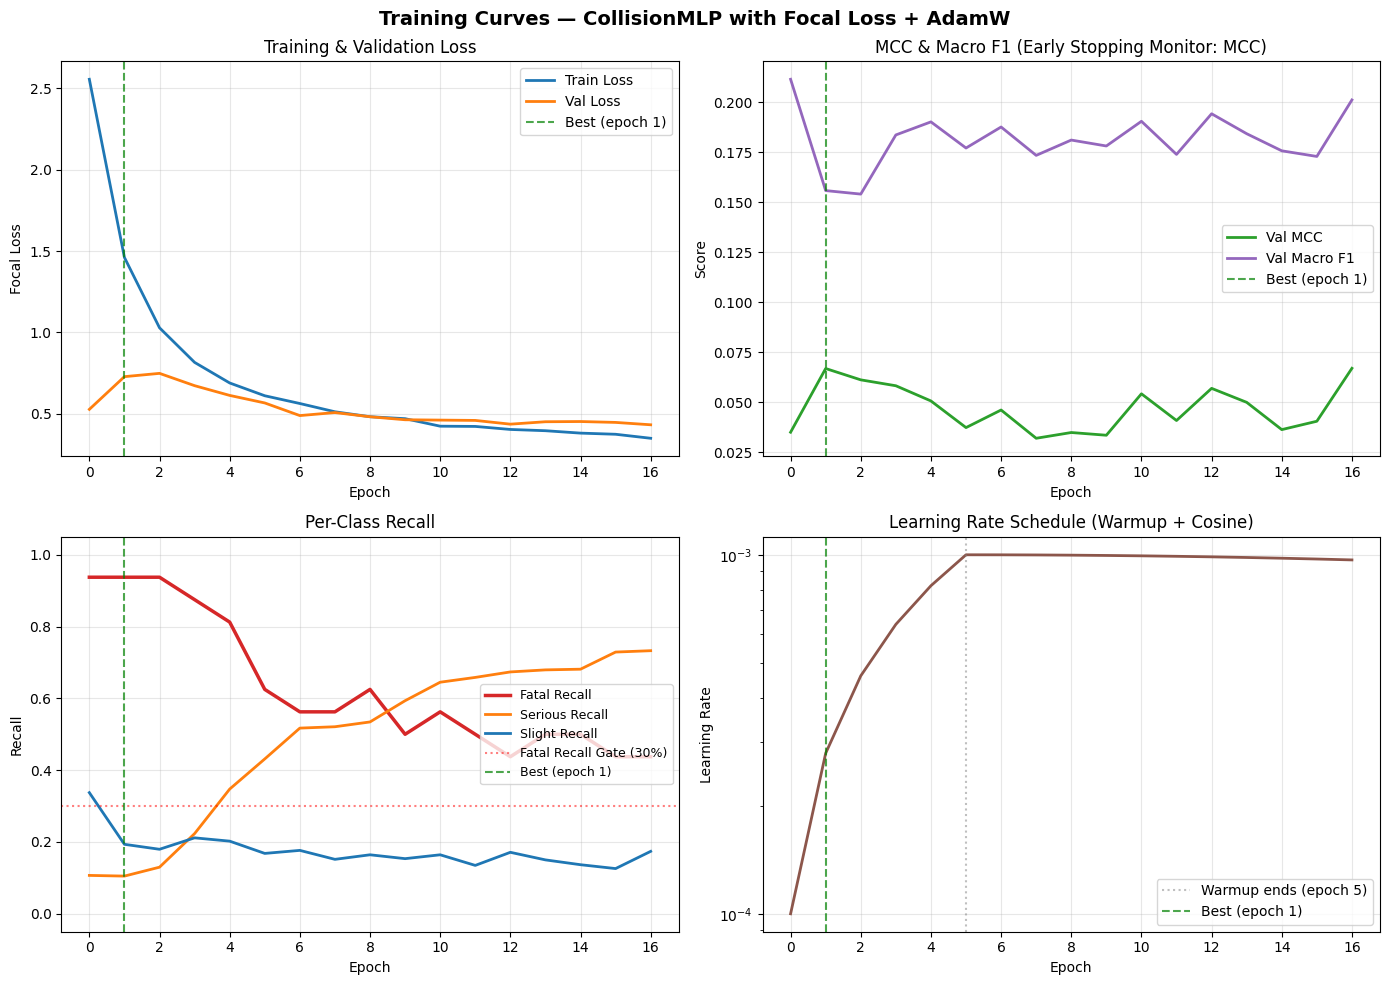

Training curves saved to outputs/figures/training_curves.png


In [7]:
# ================================================================
# Training Curves Visualisation
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Curves — CollisionMLP with Focal Loss + AdamW',
             fontsize=14, fontweight='bold')

epochs_range = range(len(history['train_loss']))
best_ep = early_stopping.best_epoch

# 1. Loss curves
ax = axes[0, 0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
ax.plot(epochs_range, history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2)
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Focal Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. MCC and Macro F1
ax = axes[0, 1]
ax.plot(epochs_range, history['val_mcc'], label='Val MCC', color='#2ca02c', linewidth=2)
ax.plot(epochs_range, history['val_macro_f1'], label='Val Macro F1', color='#9467bd', linewidth=2)
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_title('MCC & Macro F1 (Early Stopping Monitor: MCC)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Per-class Recall
ax = axes[1, 0]
ax.plot(epochs_range, history['val_fatal_recall'], label='Fatal Recall', color='#d62728', linewidth=2.5)
ax.plot(epochs_range, history['val_serious_recall'], label='Serious Recall', color='#ff7f0e', linewidth=2)
ax.plot(epochs_range, history['val_slight_recall'], label='Slight Recall', color='#1f77b4', linewidth=2)
ax.axhline(0.30, color='red', linestyle=':', alpha=0.5, label='Fatal Recall Gate (30%)')
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall')
ax.set_title('Per-Class Recall')
ax.legend(loc='center right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# 4. Learning rate schedule
ax = axes[1, 1]
ax.plot(epochs_range, history['lr'], color='#8c564b', linewidth=2)
ax.axvline(WARMUP_EPOCHS, color='gray', linestyle=':', alpha=0.5, label=f'Warmup ends (epoch {WARMUP_EPOCHS})')
ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (Warmup + Cosine)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()

os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to outputs/figures/training_curves.png")

## Step 5: Hyperparameter Sweep — Fixing the Overcorrection

### Diagnostic from Step 4

The training log revealed a critical problem: **Slight Recall never exceeded 34%** across all 17 epochs. The model learned to predict Fatal and Serious but completely ignored the majority class (82.8% of real-world collisions). This made Macro F1 plateau at 0.20 — well below the Random Forest baseline (0.31).

### Root Cause: Multiplicative Overcorrection

The `WeightedRandomSampler` already amplifies Fatal from 0.5% to 33% of every batch — a **66x boost**. Stacking `sqrt(alpha)` weights `[8.02, 1.41, 0.63]` on top creates an effective **838x boost** for Fatal vs Slight. The model has no gradient incentive to learn Slight predictions at all.

### The Fix: Controlled Sweep

We run 6 experiments varying two knobs:
- **Alpha power**: `uniform [1,1,1]`, `mild [1.3, 1.0, 0.95]`, `quarter-root [2.83, 1.19, 0.80]`
- **Focal gamma**: `1.0` (light focusing) vs `2.0` (standard focusing)

All experiments keep the Sampler (already provides 33/33/33 batches) and switch early stopping to **Macro F1** — which naturally rewards balanced performance across all three classes.

### Selection Criteria
**Composite Score** = `0.4 × Fatal_Recall + 0.3 × MCC_norm + 0.3 × Macro_F1`

Hard constraints (must pass both):
- Fatal Recall ≥ 30%
- Macro F1 > 0.31 (must beat RF baseline)

In [8]:
import pandas as pd

# ================================================================
# Experiment Grid: 3 alpha levels × 2 gamma levels = 6 experiments
# ================================================================
qrt_alpha = np.power(class_weights, 0.25).tolist()

experiments = [
    {'name': 'uniform_g2',  'label': 'Uniform, γ=2.0',      'alpha': [1.0, 1.0, 1.0],     'gamma': 2.0, 'poly_epsilon': 0.0},
    {'name': 'uniform_g1',  'label': 'Uniform, γ=1.0',      'alpha': [1.0, 1.0, 1.0],     'gamma': 1.0, 'poly_epsilon': 0.0},
    {'name': 'mild_g2',     'label': 'Mild, γ=2.0',         'alpha': [1.3, 1.0, 0.95],    'gamma': 2.0, 'poly_epsilon': 0.0},
    {'name': 'mild_g1',     'label': 'Mild, γ=1.0',         'alpha': [1.3, 1.0, 0.95],    'gamma': 1.0, 'poly_epsilon': 0.0},
    {'name': 'qrt_g2',      'label': 'Quarter-Root, γ=2.0', 'alpha': qrt_alpha,            'gamma': 2.0, 'poly_epsilon': 0.0},
    {'name': 'qrt_g1',      'label': 'Quarter-Root, γ=1.0', 'alpha': qrt_alpha,            'gamma': 1.0, 'poly_epsilon': 0.0},
]

print("Experiment Grid:")
print(f"{'#':>2}  {'Name':<22} {'Alpha':<28} {'γ':>4}  {'ε':>4}")
print("-" * 70)
for i, exp in enumerate(experiments):
    alpha_str = f"[{exp['alpha'][0]:.2f}, {exp['alpha'][1]:.2f}, {exp['alpha'][2]:.2f}]"
    print(f"{i+1:2d}  {exp['label']:<22} {alpha_str:<28} {exp['gamma']:4.1f}  {exp['poly_epsilon']:4.1f}")

# ================================================================
# Run Experiment Function
# ================================================================
def run_experiment(config, train_loader, val_loader, device, input_dim):
    """Train a model with the given config and return results."""
    
    # Fresh model with Kaiming He init
    mdl = CollisionMLP(input_dim=input_dim, num_classes=3, dropout=0.3)
    mdl.apply(init_weights)
    mdl = mdl.to(device)
    
    # Experiment-specific loss
    crit = FocalLoss(
        alpha=config['alpha'], gamma=config['gamma'],
        poly_epsilon=config.get('poly_epsilon', 0.0)
    ).to(device)
    
    # Optimizer + Scheduler (same for all experiments)
    opt = optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
    ws = torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.1, total_iters=5)
    cs = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=95, eta_min=1e-5)
    sched = torch.optim.lr_scheduler.SequentialLR(opt, schedulers=[ws, cs], milestones=[5])
    
    # Early stopping on MACRO F1 (not MCC) — rewards balanced performance
    es = EarlyStopping(patience=20, min_delta=0.001, fatal_recall_gate=0.20)
    
    hist = {'train_loss': [], 'val_loss': [], 'val_mcc': [], 'val_macro_f1': [],
            'val_fatal_recall': [], 'val_serious_recall': [], 'val_slight_recall': [], 'lr': []}
    
    for epoch in range(100):
        # Train
        mdl.train()
        rl, ns = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(mdl(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
            opt.step()
            rl += loss.item() * xb.size(0)
            ns += xb.size(0)
        
        # Evaluate
        v = evaluate(mdl, val_loader, crit, device)
        lr = opt.param_groups[0]['lr']
        sched.step()
        
        hist['train_loss'].append(rl / ns)
        hist['val_loss'].append(v['loss'])
        hist['val_mcc'].append(v['mcc'])
        hist['val_macro_f1'].append(v['macro_f1'])
        hist['val_fatal_recall'].append(v['fatal_recall'])
        hist['val_serious_recall'].append(v['serious_recall'])
        hist['val_slight_recall'].append(v['slight_recall'])
        hist['lr'].append(lr)
        
        # Early stopping monitors Macro F1
        es.step(score=v['macro_f1'], fatal_recall=v['fatal_recall'],
                model=mdl, epoch=epoch)
        if es.should_stop:
            break
    
    # Restore best and evaluate
    es.restore_best(mdl)
    final = evaluate(mdl, val_loader, crit, device)
    
    # Composite score
    comp = 0.4 * final['fatal_recall'] + 0.3 * (final['mcc'] + 1) / 2 + 0.3 * final['macro_f1']
    
    return {
        'config': config,
        'best_epoch': es.best_epoch,
        'epochs_trained': len(hist['train_loss']),
        'metrics': final,
        'composite': comp,
        'history': hist,
        'model_state': copy.deepcopy(mdl.state_dict()),
    }

print(f"\nReady to run {len(experiments)} experiments.")

Experiment Grid:
 #  Name                   Alpha                           γ     ε
----------------------------------------------------------------------
 1  Uniform, γ=2.0         [1.00, 1.00, 1.00]            2.0   0.0
 2  Uniform, γ=1.0         [1.00, 1.00, 1.00]            1.0   0.0
 3  Mild, γ=2.0            [1.30, 1.00, 0.95]            2.0   0.0
 4  Mild, γ=1.0            [1.30, 1.00, 0.95]            1.0   0.0
 5  Quarter-Root, γ=2.0    [2.83, 1.19, 0.80]            2.0   0.0
 6  Quarter-Root, γ=1.0    [2.83, 1.19, 0.80]            1.0   0.0

Ready to run 6 experiments.


In [9]:
# ================================================================
# Execute All Experiments
# ================================================================
results = []
sweep_start = time.time()

for i, exp in enumerate(experiments):
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"  Experiment {i+1}/{len(experiments)}: {exp['label']}")
    print(f"  Alpha: [{exp['alpha'][0]:.2f}, {exp['alpha'][1]:.2f}, {exp['alpha'][2]:.2f}]")
    print(f"{'='*60}")
    
    result = run_experiment(exp, train_loader, val_loader, device, X_train.shape[1])
    results.append(result)
    
    m = result['metrics']
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s | Best epoch: {result['best_epoch']} / {result['epochs_trained']}")
    print(f"  Fatal R: {m['fatal_recall']:.3f} | Serious R: {m['serious_recall']:.3f} | "
          f"Slight R: {m['slight_recall']:.3f}")
    print(f"  MCC: {m['mcc']:.4f} | Macro F1: {m['macro_f1']:.4f} | "
          f"Composite: {result['composite']:.4f}")

total_time = time.time() - sweep_start
print(f"\n{'='*60}")
print(f"  All {len(experiments)} experiments completed in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"{'='*60}")


  Experiment 1/6: Uniform, γ=2.0
  Alpha: [1.00, 1.00, 1.00]


  Done in 72.2s | Best epoch: 8 / 29
  Fatal R: 0.500 | Serious R: 0.355 | Slight R: 0.573
  MCC: 0.0987 | Macro F1: 0.3289 | Composite: 0.4635

  Experiment 2/6: Uniform, γ=1.0
  Alpha: [1.00, 1.00, 1.00]


  Done in 77.8s | Best epoch: 10 / 31
  Fatal R: 0.375 | Serious R: 0.447 | Slight R: 0.577
  MCC: 0.1283 | Macro F1: 0.3421 | Composite: 0.4219

  Experiment 3/6: Mild, γ=2.0
  Alpha: [1.30, 1.00, 0.95]


  Done in 78.2s | Best epoch: 11 / 32
  Fatal R: 0.375 | Serious R: 0.477 | Slight R: 0.459
  MCC: 0.0830 | Macro F1: 0.2998 | Composite: 0.4024

  Experiment 4/6: Mild, γ=1.0
  Alpha: [1.30, 1.00, 0.95]


  Done in 67.2s | Best epoch: 0 / 21
  Fatal R: 0.250 | Serious R: 0.344 | Slight R: 0.639
  MCC: 0.0759 | Macro F1: 0.3375 | Composite: 0.3626

  Experiment 5/6: Quarter-Root, γ=2.0
  Alpha: [2.83, 1.19, 0.80]


  Done in 93.6s | Best epoch: 12 / 33
  Fatal R: 0.438 | Serious R: 0.651 | Slight R: 0.269
  MCC: 0.0862 | Macro F1: 0.2429 | Composite: 0.4108

  Experiment 6/6: Quarter-Root, γ=1.0
  Alpha: [2.83, 1.19, 0.80]


  Done in 85.1s | Best epoch: 9 / 30
  Fatal R: 0.375 | Serious R: 0.609 | Slight R: 0.317
  MCC: 0.0843 | Macro F1: 0.2586 | Composite: 0.3902

  All 6 experiments completed in 474.0s (7.9 min)


In [10]:
# ================================================================
# Results Comparison Table + Winner Selection
# ================================================================

# Build results DataFrame
rows = []
for r in results:
    m = r['metrics']
    rows.append({
        'Experiment': r['config']['label'],
        'Alpha': f"[{r['config']['alpha'][0]:.2f}, {r['config']['alpha'][1]:.2f}, {r['config']['alpha'][2]:.2f}]",
        'γ': r['config']['gamma'],
        'Best Epoch': r['best_epoch'],
        'Fatal R': round(m['fatal_recall'], 4),
        'Serious R': round(m['serious_recall'], 4),
        'Slight R': round(m['slight_recall'], 4),
        'MCC': round(m['mcc'], 4),
        'Macro F1': round(m['macro_f1'], 4),
        'Composite': round(r['composite'], 4),
    })

df = pd.DataFrame(rows)

# Apply hard constraints
RF_MACRO_F1 = 0.3088
df['Passes'] = (df['Fatal R'] >= 0.30) & (df['Macro F1'] > RF_MACRO_F1)

print("=" * 100)
print("  HYPERPARAMETER SWEEP — RESULTS COMPARISON")
print("=" * 100)
print(df.to_string(index=False))
print()

# Select winner among passing experiments
passing = df[df['Passes']].copy()
if len(passing) > 0:
    winner_idx = passing['Composite'].idxmax()
    winner_name = df.loc[winner_idx, 'Experiment']
    winner_result = results[winner_idx]
    
    print(f"WINNER: {winner_name} (Composite Score = {df.loc[winner_idx, 'Composite']:.4f})")
    print(f"  Passes both constraints: Fatal R >= 30% and Macro F1 > RF baseline ({RF_MACRO_F1:.4f})")
    
    # Save winning model
    wm = winner_result['metrics']
    torch.save({
        'model_state_dict': winner_result['model_state'],
        'epoch': winner_result['best_epoch'],
        'val_metrics': wm,
        'composite_score': winner_result['composite'],
        'config': {
            'input_dim': X_train.shape[1],
            'num_classes': 3,
            'dropout': 0.3,
            'architecture': '21 -> 128 -> 64 -> 32 -> 3',
            'optimizer': 'AdamW',
            'base_lr': 1e-3,
            'weight_decay': 1e-4,
            'focal_gamma': winner_result['config']['gamma'],
            'focal_alpha': winner_result['config']['alpha'],
            'poly_epsilon': winner_result['config'].get('poly_epsilon', 0.0),
            'early_stopping_metric': 'macro_f1',
            'early_stopping_patience': 20,
        },
    }, '../outputs/models/best_mlp_model.pt')
    print(f"\n  Best model saved to outputs/models/best_mlp_model.pt")
    
    # Load winning weights into the active model for downstream use
    model = CollisionMLP(input_dim=X_train.shape[1], num_classes=3, dropout=0.3).to(device)
    model.load_state_dict(winner_result['model_state'])
    model.eval()
    
    # Update criterion to match winner config
    criterion = FocalLoss(
        alpha=winner_result['config']['alpha'],
        gamma=winner_result['config']['gamma'],
        poly_epsilon=winner_result['config'].get('poly_epsilon', 0.0)
    ).to(device)
    
    print(f"  Active model updated to winning configuration.")
else:
    print("WARNING: No experiment passed both hard constraints.")
    print("  Selecting best composite score regardless of constraints.")
    winner_idx = df['Composite'].idxmax()
    winner_name = df.loc[winner_idx, 'Experiment']
    winner_result = results[winner_idx]
    print(f"  Best available: {winner_name} (Composite = {df.loc[winner_idx, 'Composite']:.4f})")

# Compare winner vs RF baseline
baseline = joblib.load('../outputs/models/baseline_results.joblib')
print(f"\n{'='*55}")
print(f"  WINNER vs RANDOM FOREST BASELINE")
print(f"{'='*55}")
print(f"  {'Metric':<18} {'MLP (Winner)':>12} {'RF Baseline':>12} {'Delta':>10}")
print(f"  {'-'*52}")
for metric, rf_key in [('Fatal Recall', 'fatal_recall'), ('Macro F1', 'macro_f1'), ('MCC', 'mcc')]:
    mlp_val = wm[rf_key.replace(' ', '_').lower()] if isinstance(wm, dict) else 0
    rf_val = baseline.get(rf_key, 0)
    delta = mlp_val - rf_val
    sign = '+' if delta >= 0 else ''
    print(f"  {metric:<18} {mlp_val:12.4f} {rf_val:12.4f} {sign}{delta:9.4f}")

# Save sweep results for analysis
joblib.dump({
    'results': [{k: v for k, v in r.items() if k != 'model_state'} for r in results],
    'winner_idx': winner_idx,
    'comparison_df': df,
}, '../outputs/models/sweep_results.joblib')
print(f"\n  Sweep results saved to outputs/models/sweep_results.joblib")

  HYPERPARAMETER SWEEP — RESULTS COMPARISON


         Experiment              Alpha   γ  Best Epoch  Fatal R  Serious R  Slight R    MCC  Macro F1  Composite  Passes
     Uniform, γ=2.0 [1.00, 1.00, 1.00] 2.0           8   0.5000     0.3550    0.5727 0.0987    0.3289     0.4635    True
     Uniform, γ=1.0 [1.00, 1.00, 1.00] 1.0          10   0.3750     0.4466    0.5770 0.1283    0.3421     0.4219    True
        Mild, γ=2.0 [1.30, 1.00, 0.95] 2.0          11   0.3750     0.4771    0.4591 0.0830    0.2998     0.4024   False
        Mild, γ=1.0 [1.30, 1.00, 0.95] 1.0           0   0.2500     0.3435    0.6392 0.0759    0.3375     0.3626   False
Quarter-Root, γ=2.0 [2.83, 1.19, 0.80] 2.0          12   0.4375     0.6508    0.2695 0.0862    0.2429     0.4108   False
Quarter-Root, γ=1.0 [2.83, 1.19, 0.80] 1.0           9   0.3750     0.6088    0.3175 0.0843    0.2586     0.3902   False

WINNER: Uniform, γ=2.0 (Composite Score = 0.4635)
  Passes both constraints: Fatal R >= 30% and Macro F1 > RF baseline (0.3088)

  Best model saved to o


  WINNER vs RANDOM FOREST BASELINE
  Metric             MLP (Winner)  RF Baseline      Delta
  ----------------------------------------------------
  Fatal Recall             0.5000       0.0000 +   0.5000
  Macro F1                 0.3289       0.3088 +   0.0201
  MCC                      0.0987       0.0277 +   0.0710

  Sweep results saved to outputs/models/sweep_results.joblib


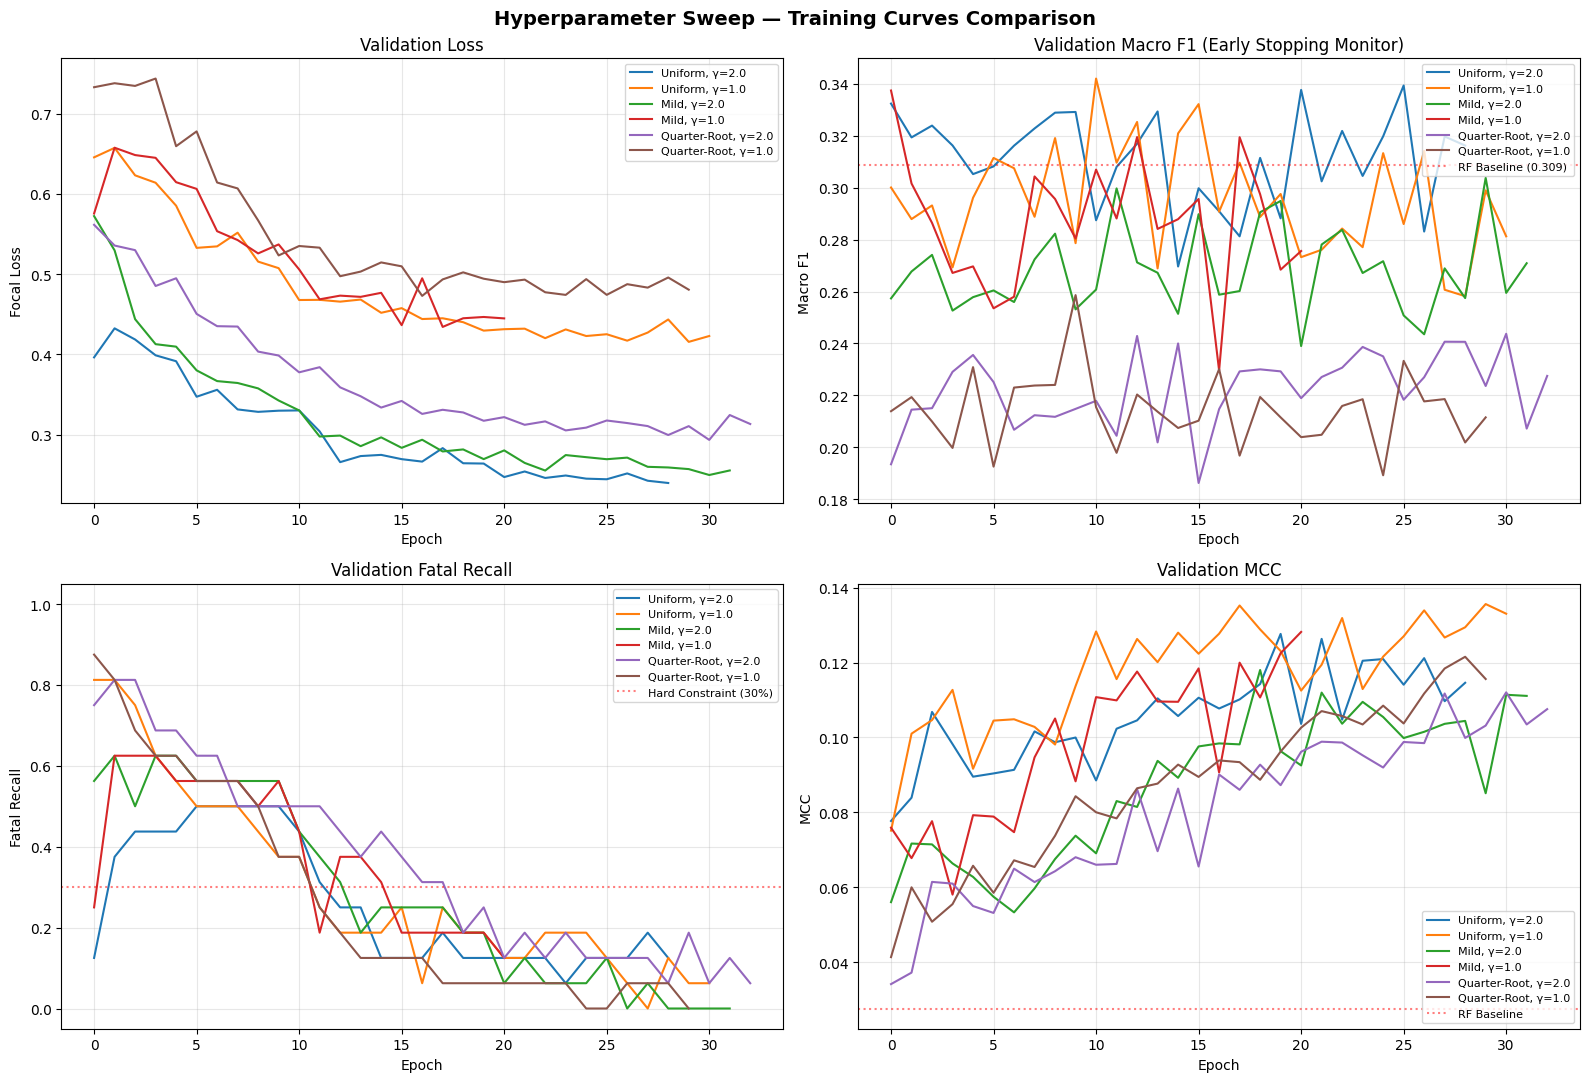

Sweep comparison saved to outputs/figures/sweep_comparison.png


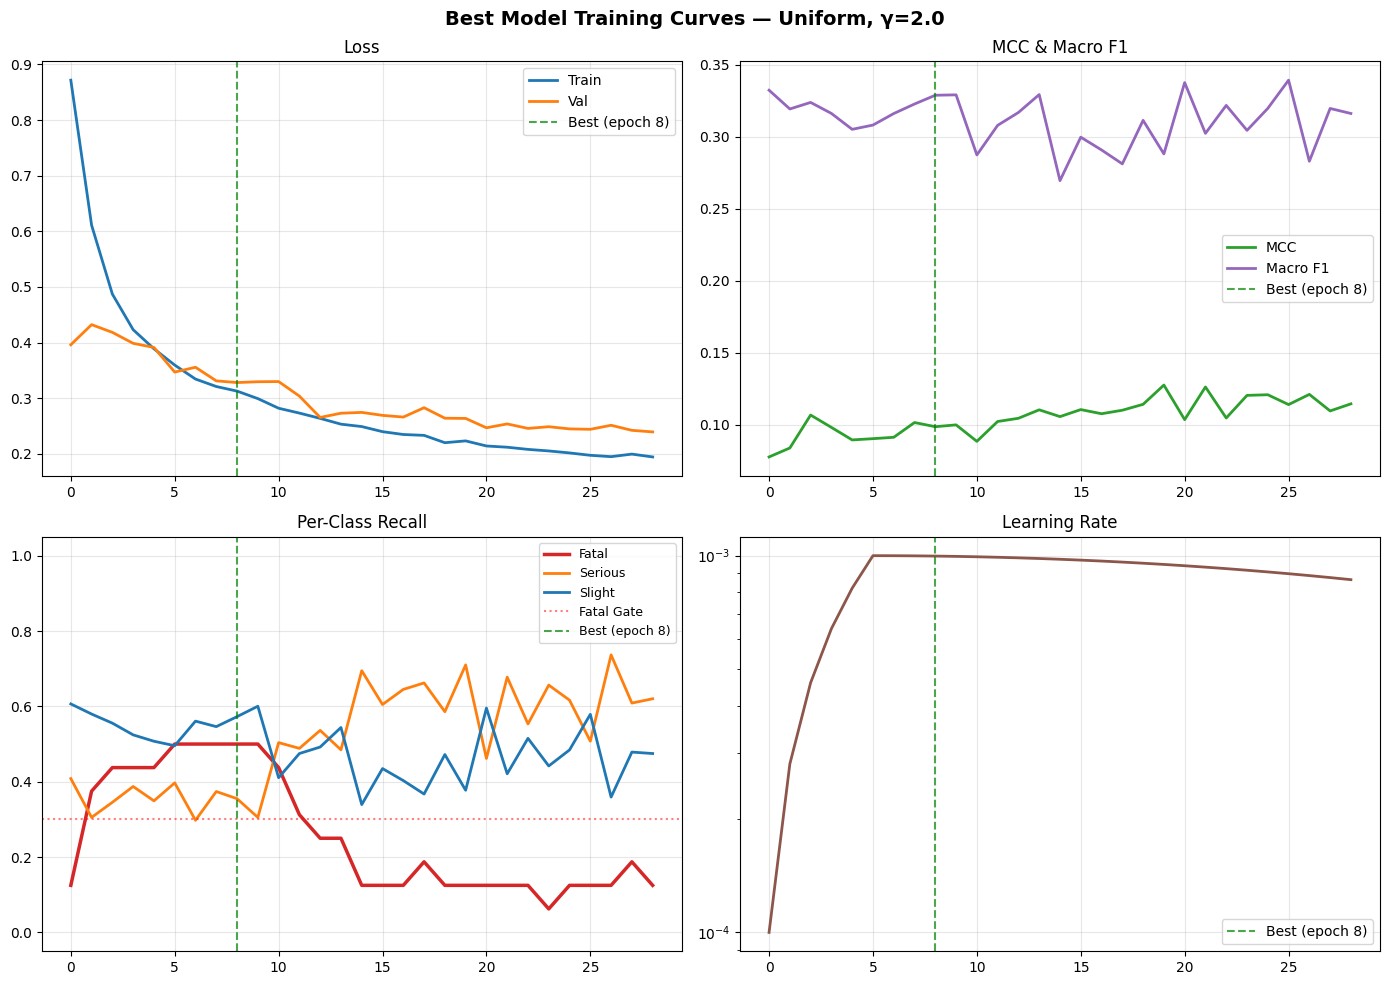

Best model curves saved to outputs/figures/best_model_training_curves.png


In [11]:
# ================================================================
# Training Curves — All Experiments Side by Side
# ================================================================
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Hyperparameter Sweep — Training Curves Comparison', fontsize=14, fontweight='bold')

for i, r in enumerate(results):
    h = r['history']
    ep = range(len(h['train_loss']))
    label = r['config']['label']
    c = colors[i]
    
    # Val Loss
    axes[0, 0].plot(ep, h['val_loss'], label=label, color=c, linewidth=1.5)
    # Macro F1
    axes[0, 1].plot(ep, h['val_macro_f1'], label=label, color=c, linewidth=1.5)
    # Fatal Recall
    axes[1, 0].plot(ep, h['val_fatal_recall'], label=label, color=c, linewidth=1.5)
    # MCC
    axes[1, 1].plot(ep, h['val_mcc'], label=label, color=c, linewidth=1.5)

axes[0, 0].set_title('Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Focal Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Validation Macro F1 (Early Stopping Monitor)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Macro F1')
axes[0, 1].axhline(RF_MACRO_F1, color='red', linestyle=':', alpha=0.5, label=f'RF Baseline ({RF_MACRO_F1:.3f})')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Validation Fatal Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Fatal Recall')
axes[1, 0].axhline(0.30, color='red', linestyle=':', alpha=0.5, label='Hard Constraint (30%)')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-0.05, 1.05)

axes[1, 1].set_title('Validation MCC')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MCC')
axes[1, 1].axhline(baseline.get('mcc', 0.028), color='red', linestyle=':', alpha=0.5, label=f'RF Baseline')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/sweep_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sweep comparison saved to outputs/figures/sweep_comparison.png")

# --- Winner's detailed training curves ---
wh = winner_result['history']
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle(f'Best Model Training Curves — {winner_name}', fontsize=14, fontweight='bold')

ep = range(len(wh['train_loss']))
best_ep = winner_result['best_epoch']

axes2[0, 0].plot(ep, wh['train_loss'], label='Train', color='#1f77b4', linewidth=2)
axes2[0, 0].plot(ep, wh['val_loss'], label='Val', color='#ff7f0e', linewidth=2)
axes2[0, 0].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
axes2[0, 0].set_title('Loss')
axes2[0, 0].legend()
axes2[0, 0].grid(True, alpha=0.3)

axes2[0, 1].plot(ep, wh['val_mcc'], label='MCC', color='#2ca02c', linewidth=2)
axes2[0, 1].plot(ep, wh['val_macro_f1'], label='Macro F1', color='#9467bd', linewidth=2)
axes2[0, 1].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
axes2[0, 1].set_title('MCC & Macro F1')
axes2[0, 1].legend()
axes2[0, 1].grid(True, alpha=0.3)

axes2[1, 0].plot(ep, wh['val_fatal_recall'], label='Fatal', color='#d62728', linewidth=2.5)
axes2[1, 0].plot(ep, wh['val_serious_recall'], label='Serious', color='#ff7f0e', linewidth=2)
axes2[1, 0].plot(ep, wh['val_slight_recall'], label='Slight', color='#1f77b4', linewidth=2)
axes2[1, 0].axhline(0.30, color='red', linestyle=':', alpha=0.5, label='Fatal Gate')
axes2[1, 0].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
axes2[1, 0].set_title('Per-Class Recall')
axes2[1, 0].legend(fontsize=9)
axes2[1, 0].grid(True, alpha=0.3)
axes2[1, 0].set_ylim(-0.05, 1.05)

axes2[1, 1].plot(ep, wh['lr'], color='#8c564b', linewidth=2)
axes2[1, 1].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best (epoch {best_ep})')
axes2[1, 1].set_title('Learning Rate')
axes2[1, 1].set_yscale('log')
axes2[1, 1].legend()
axes2[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/best_model_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Best model curves saved to outputs/figures/best_model_training_curves.png")

## Step 6: Decision Threshold Optimisation

The model currently uses `argmax` — whichever class has the highest probability wins. But in a **safety-critical** application like collision severity prediction, we want to **catch Fatal crashes even when the model is only moderately confident**.

**Approach**: Instead of equal thresholds (0.33 each), we systematically search for a lower Fatal threshold. If the model's P(Fatal) exceeds this threshold, we predict Fatal regardless of other class probabilities. This trades some false alarms for dramatically fewer missed fatalities.

We search thresholds from 0.05 to 0.50 in steps of 0.01, selecting the threshold that **maximises Fatal Recall** while keeping **Macro F1 above the RF baseline** (0.309).

Validation set: 3145 samples
  Fatal: 16, Serious: 524, Slight: 2605

Mean model probabilities per class:
  Fatal: 0.1460 (min=0.0000, max=0.7482)
  Serious: 0.4173 (min=0.1970, max=0.5088)
  Slight: 0.4366 (min=0.0549, max=0.6654)

Argmax Baseline:
  Fatal R: 0.5000 | Serious R: 0.3550 | Slight R: 0.5727
  MCC: 0.0987 | Macro F1: 0.3289

  FATAL THRESHOLD SEARCH
 Threshold  Fatal R  Serious R  Slight R     MCC  Macro F1  Pass
-----------------------------------------------------------------
      0.05   0.9375     0.0286    0.4994  0.0648    0.2349      
      0.06   0.8750     0.0401    0.5205  0.0682    0.2459      
      0.07   0.7500     0.0477    0.5305  0.0670    0.2509      
      0.08   0.7500     0.0649    0.5413  0.0721    0.2615      
      0.09   0.7500     0.0782    0.5482  0.0713    0.2680      
      0.10   0.7500     0.0897    0.5516  0.0743    0.2732      
      0.11   0.5625     0.0992    0.5547  0.0718    0.2755      
      0.12   0.5625     0.1088    0.5585  0.0728

      0.44   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.45   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.46   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.47   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.48   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.49   0.5000     0.3550    0.5727  0.0987    0.3289     ✓
      0.50   0.5000     0.3550    0.5727  0.0987    0.3289     ✓

  OPTIMAL THRESHOLD FOUND: 0.37
  Fatal Recall:   0.5000  (argmax: 0.5000)
  Serious Recall: 0.3550  (argmax: 0.3550)
  Slight Recall:  0.5727  (argmax: 0.5727)
  MCC:            0.0987  (argmax: 0.0987)
  Macro F1:       0.3289  (argmax: 0.3289)


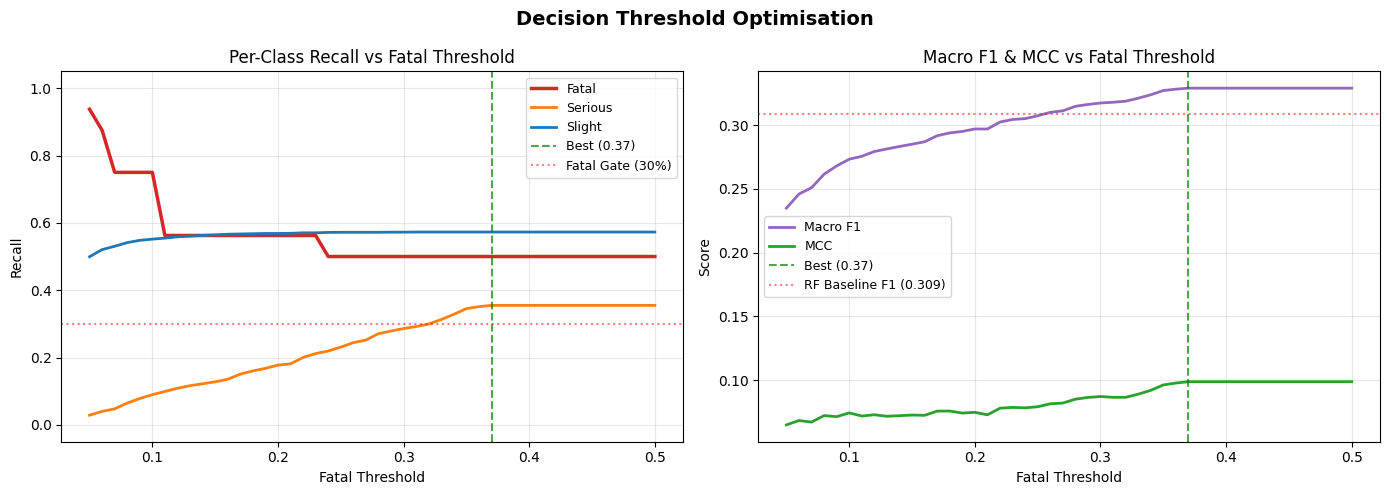

Threshold optimisation chart saved to outputs/figures/threshold_optimisation.png


In [12]:
# ================================================================
# Step 6: Decision Threshold Optimisation
# ================================================================
from sklearn.metrics import classification_report, confusion_matrix

# --- 6a. Get model probabilities on validation set ---
model.eval()
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y_batch.numpy())

val_probs = np.concatenate(all_probs, axis=0)    # (N, 3)
val_targets = np.concatenate(all_targets, axis=0)  # (N,)

print(f"Validation set: {len(val_targets)} samples")
print(f"  Fatal: {(val_targets == 0).sum()}, Serious: {(val_targets == 1).sum()}, Slight: {(val_targets == 2).sum()}")
print(f"\nMean model probabilities per class:")
for cls, name in enumerate(['Fatal', 'Serious', 'Slight']):
    print(f"  {name}: {val_probs[:, cls].mean():.4f} (min={val_probs[:, cls].min():.4f}, max={val_probs[:, cls].max():.4f})")

# --- 6b. Argmax baseline (current approach) ---
argmax_preds = val_probs.argmax(axis=1)
argmax_recall = recall_score(val_targets, argmax_preds, average=None, labels=[0, 1, 2], zero_division=0)
argmax_mcc = matthews_corrcoef(val_targets, argmax_preds)
argmax_f1 = f1_score(val_targets, argmax_preds, average='macro', zero_division=0)

print(f"\nArgmax Baseline:")
print(f"  Fatal R: {argmax_recall[0]:.4f} | Serious R: {argmax_recall[1]:.4f} | Slight R: {argmax_recall[2]:.4f}")
print(f"  MCC: {argmax_mcc:.4f} | Macro F1: {argmax_f1:.4f}")

# --- 6c. Threshold search for Fatal class ---
print(f"\n{'='*70}")
print(f"  FATAL THRESHOLD SEARCH")
print(f"{'='*70}")
print(f"{'Threshold':>10} {'Fatal R':>8} {'Serious R':>10} {'Slight R':>9} {'MCC':>7} {'Macro F1':>9} {'Pass':>5}")
print("-" * 65)

threshold_results = []
RF_MACRO_F1 = 0.3088

for thresh in np.arange(0.05, 0.51, 0.01):
    # Apply threshold: predict Fatal if P(Fatal) > thresh, else argmax of remaining
    preds = val_probs.argmax(axis=1).copy()
    fatal_mask = val_probs[:, 0] >= thresh
    preds[fatal_mask] = 0
    
    per_recall = recall_score(val_targets, preds, average=None, labels=[0, 1, 2], zero_division=0)
    mcc = matthews_corrcoef(val_targets, preds)
    macro_f1 = f1_score(val_targets, preds, average='macro', zero_division=0)
    
    passes = per_recall[0] >= 0.30 and macro_f1 > RF_MACRO_F1
    
    threshold_results.append({
        'threshold': thresh,
        'fatal_recall': per_recall[0],
        'serious_recall': per_recall[1],
        'slight_recall': per_recall[2],
        'mcc': mcc,
        'macro_f1': macro_f1,
        'passes': passes,
    })
    
    flag = "✓" if passes else ""
    print(f"{thresh:10.2f} {per_recall[0]:8.4f} {per_recall[1]:10.4f} {per_recall[2]:9.4f} "
          f"{mcc:7.4f} {macro_f1:9.4f} {flag:>5}")

# --- 6d. Select best threshold ---
passing_thresholds = [r for r in threshold_results if r['passes']]

if passing_thresholds:
    # Among passing thresholds, maximise Fatal Recall
    best_thresh_result = max(passing_thresholds, key=lambda r: r['fatal_recall'])
    # If tie on Fatal Recall, pick the one with best Macro F1
    max_fatal = best_thresh_result['fatal_recall']
    ties = [r for r in passing_thresholds if r['fatal_recall'] == max_fatal]
    if len(ties) > 1:
        best_thresh_result = max(ties, key=lambda r: r['macro_f1'])
    
    best_threshold = best_thresh_result['threshold']
    
    print(f"\n{'='*70}")
    print(f"  OPTIMAL THRESHOLD FOUND: {best_threshold:.2f}")
    print(f"{'='*70}")
    print(f"  Fatal Recall:   {best_thresh_result['fatal_recall']:.4f}  (argmax: {argmax_recall[0]:.4f})")
    print(f"  Serious Recall: {best_thresh_result['serious_recall']:.4f}  (argmax: {argmax_recall[1]:.4f})")
    print(f"  Slight Recall:  {best_thresh_result['slight_recall']:.4f}  (argmax: {argmax_recall[2]:.4f})")
    print(f"  MCC:            {best_thresh_result['mcc']:.4f}  (argmax: {argmax_mcc:.4f})")
    print(f"  Macro F1:       {best_thresh_result['macro_f1']:.4f}  (argmax: {argmax_f1:.4f})")
else:
    print("\nNo threshold passed both constraints. Using argmax.")
    best_threshold = None
    best_thresh_result = {
        'threshold': 0.33, 'fatal_recall': argmax_recall[0],
        'serious_recall': argmax_recall[1], 'slight_recall': argmax_recall[2],
        'mcc': argmax_mcc, 'macro_f1': argmax_f1,
    }

# --- 6e. Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Decision Threshold Optimisation', fontsize=14, fontweight='bold')

thresholds = [r['threshold'] for r in threshold_results]

# Left: Recall vs Threshold
axes[0].plot(thresholds, [r['fatal_recall'] for r in threshold_results], 
             label='Fatal', color='#d62728', linewidth=2.5)
axes[0].plot(thresholds, [r['serious_recall'] for r in threshold_results],
             label='Serious', color='#ff7f0e', linewidth=2)
axes[0].plot(thresholds, [r['slight_recall'] for r in threshold_results],
             label='Slight', color='#1f77b4', linewidth=2)
if best_threshold:
    axes[0].axvline(best_threshold, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_threshold:.2f})')
axes[0].axhline(0.30, color='red', linestyle=':', alpha=0.5, label='Fatal Gate (30%)')
axes[0].set_xlabel('Fatal Threshold')
axes[0].set_ylabel('Recall')
axes[0].set_title('Per-Class Recall vs Fatal Threshold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Right: Macro F1 & MCC vs Threshold
axes[1].plot(thresholds, [r['macro_f1'] for r in threshold_results],
             label='Macro F1', color='#9467bd', linewidth=2)
axes[1].plot(thresholds, [r['mcc'] for r in threshold_results],
             label='MCC', color='#2ca02c', linewidth=2)
if best_threshold:
    axes[1].axvline(best_threshold, color='green', linestyle='--', alpha=0.7, label=f'Best ({best_threshold:.2f})')
axes[1].axhline(RF_MACRO_F1, color='red', linestyle=':', alpha=0.5, label=f'RF Baseline F1 ({RF_MACRO_F1:.3f})')
axes[1].set_xlabel('Fatal Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Macro F1 & MCC vs Fatal Threshold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Threshold optimisation chart saved to outputs/figures/threshold_optimisation.png")

## Step 7: MLP Ensemble (Prediction Averaging)

We already trained 6 models in the sweep. Instead of relying on a single winner, we can **average the softmax probabilities** from the top-performing models. This reduces prediction variance — important when Fatal validation samples are so few that individual model selection is noisy.

**Approach**: Select models that passed both hard constraints (Fatal Recall ≥ 30% and Macro F1 > RF baseline), average their softmax outputs, then apply the optimised threshold from Step 6.

In [13]:
# ================================================================
# Step 7: MLP Ensemble — Average Top Models
# ================================================================

# --- 7a. Identify passing models from sweep ---
passing_indices = []
for i, r in enumerate(results):
    m = r['metrics']
    if m['fatal_recall'] >= 0.30 and m['macro_f1'] > RF_MACRO_F1:
        passing_indices.append(i)
        print(f"  Model {i+1} ({r['config']['label']}): "
              f"Fatal R={m['fatal_recall']:.3f}, Macro F1={m['macro_f1']:.4f}, "
              f"Composite={r['composite']:.4f} — INCLUDED")
    else:
        print(f"  Model {i+1} ({r['config']['label']}): "
              f"Fatal R={m['fatal_recall']:.3f}, Macro F1={m['macro_f1']:.4f} — excluded")

if len(passing_indices) < 2:
    # If fewer than 2 passed, take top 3 by composite score
    print(f"\nOnly {len(passing_indices)} model(s) passed constraints. Using top 3 by composite score instead.")
    sorted_indices = sorted(range(len(results)), key=lambda i: results[i]['composite'], reverse=True)
    passing_indices = sorted_indices[:3]
    for i in passing_indices:
        r = results[i]
        print(f"  Model {i+1} ({r['config']['label']}): Composite={r['composite']:.4f}")

print(f"\nEnsemble uses {len(passing_indices)} models.")

# --- 7b. Get averaged probabilities ---
ensemble_probs = np.zeros_like(val_probs)

for idx in passing_indices:
    # Load model weights
    mdl = CollisionMLP(input_dim=X_train.shape[1], num_classes=3, dropout=0.3).to(device)
    mdl.load_state_dict(results[idx]['model_state'])
    mdl.eval()
    
    model_probs = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            logits = mdl(X_batch)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            model_probs.append(probs)
    
    ensemble_probs += np.concatenate(model_probs, axis=0)

ensemble_probs /= len(passing_indices)

# --- 7c. Evaluate with argmax ---
ens_argmax_preds = ensemble_probs.argmax(axis=1)
ens_recall = recall_score(val_targets, ens_argmax_preds, average=None, labels=[0, 1, 2], zero_division=0)
ens_mcc = matthews_corrcoef(val_targets, ens_argmax_preds)
ens_f1 = f1_score(val_targets, ens_argmax_preds, average='macro', zero_division=0)

print(f"\nEnsemble (argmax):")
print(f"  Fatal R: {ens_recall[0]:.4f} | Serious R: {ens_recall[1]:.4f} | Slight R: {ens_recall[2]:.4f}")
print(f"  MCC: {ens_mcc:.4f} | Macro F1: {ens_f1:.4f}")

# --- 7d. Evaluate with optimised threshold ---
if best_threshold is not None:
    ens_thresh_preds = ensemble_probs.argmax(axis=1).copy()
    ens_thresh_preds[ensemble_probs[:, 0] >= best_threshold] = 0
    
    ens_t_recall = recall_score(val_targets, ens_thresh_preds, average=None, labels=[0, 1, 2], zero_division=0)
    ens_t_mcc = matthews_corrcoef(val_targets, ens_thresh_preds)
    ens_t_f1 = f1_score(val_targets, ens_thresh_preds, average='macro', zero_division=0)
    
    print(f"\nEnsemble + Threshold ({best_threshold:.2f}):")
    print(f"  Fatal R: {ens_t_recall[0]:.4f} | Serious R: {ens_t_recall[1]:.4f} | Slight R: {ens_t_recall[2]:.4f}")
    print(f"  MCC: {ens_t_mcc:.4f} | Macro F1: {ens_t_f1:.4f}")

# --- 7e. Also search for ensemble-specific optimal threshold ---
print(f"\n{'='*70}")
print(f"  ENSEMBLE THRESHOLD SEARCH")
print(f"{'='*70}")

ens_threshold_results = []
for thresh in np.arange(0.05, 0.51, 0.01):
    preds = ensemble_probs.argmax(axis=1).copy()
    preds[ensemble_probs[:, 0] >= thresh] = 0
    
    per_recall = recall_score(val_targets, preds, average=None, labels=[0, 1, 2], zero_division=0)
    mcc = matthews_corrcoef(val_targets, preds)
    macro_f1 = f1_score(val_targets, preds, average='macro', zero_division=0)
    passes = per_recall[0] >= 0.30 and macro_f1 > RF_MACRO_F1
    
    ens_threshold_results.append({
        'threshold': thresh, 'fatal_recall': per_recall[0],
        'serious_recall': per_recall[1], 'slight_recall': per_recall[2],
        'mcc': mcc, 'macro_f1': macro_f1, 'passes': passes,
    })

ens_passing = [r for r in ens_threshold_results if r['passes']]
if ens_passing:
    ens_best = max(ens_passing, key=lambda r: r['fatal_recall'])
    max_fr = ens_best['fatal_recall']
    ties = [r for r in ens_passing if r['fatal_recall'] == max_fr]
    if len(ties) > 1:
        ens_best = max(ties, key=lambda r: r['macro_f1'])
    
    print(f"  Ensemble optimal threshold: {ens_best['threshold']:.2f}")
    print(f"  Fatal R: {ens_best['fatal_recall']:.4f} | Serious R: {ens_best['serious_recall']:.4f} | "
          f"Slight R: {ens_best['slight_recall']:.4f}")
    print(f"  MCC: {ens_best['mcc']:.4f} | Macro F1: {ens_best['macro_f1']:.4f}")
else:
    ens_best = None
    print("  No threshold passed constraints for ensemble.")

# --- 7f. Summary comparison ---
print(f"\n{'='*70}")
print(f"  STEP 6-7 COMPARISON")
print(f"{'='*70}")
print(f"  {'Method':<30} {'Fatal R':>8} {'Serious R':>10} {'Slight R':>9} {'MCC':>7} {'Macro F1':>9}")
print(f"  {'-'*73}")
print(f"  {'Single Model (argmax)':<30} {argmax_recall[0]:8.4f} {argmax_recall[1]:10.4f} {argmax_recall[2]:9.4f} "
      f"{argmax_mcc:7.4f} {argmax_f1:9.4f}")
if best_threshold:
    label_s = f"Single + Threshold ({best_threshold:.2f})"
    print(f"  {label_s:<30} {best_thresh_result['fatal_recall']:8.4f} "
          f"{best_thresh_result['serious_recall']:10.4f} {best_thresh_result['slight_recall']:9.4f} "
          f"{best_thresh_result['mcc']:7.4f} {best_thresh_result['macro_f1']:9.4f}")
print(f"  {'Ensemble (argmax)':<30} {ens_recall[0]:8.4f} {ens_recall[1]:10.4f} {ens_recall[2]:9.4f} "
      f"{ens_mcc:7.4f} {ens_f1:9.4f}")
if ens_best:
    label_e = f"Ensemble + Threshold ({ens_best['threshold']:.2f})"
    print(f"  {label_e:<30} {ens_best['fatal_recall']:8.4f} "
          f"{ens_best['serious_recall']:10.4f} {ens_best['slight_recall']:9.4f} "
          f"{ens_best['mcc']:7.4f} {ens_best['macro_f1']:9.4f}")
print(f"  {'-'*73}")
print(f"  {'RF Baseline':<30} {'0.0000':>8} {'0.2854':>10} {'0.9590':>9} {'0.0277':>7} {'0.3088':>9}")

  Model 1 (Uniform, γ=2.0): Fatal R=0.500, Macro F1=0.3289, Composite=0.4635 — INCLUDED
  Model 2 (Uniform, γ=1.0): Fatal R=0.375, Macro F1=0.3421, Composite=0.4219 — INCLUDED
  Model 3 (Mild, γ=2.0): Fatal R=0.375, Macro F1=0.2998 — excluded
  Model 4 (Mild, γ=1.0): Fatal R=0.250, Macro F1=0.3375 — excluded
  Model 5 (Quarter-Root, γ=2.0): Fatal R=0.438, Macro F1=0.2429 — excluded
  Model 6 (Quarter-Root, γ=1.0): Fatal R=0.375, Macro F1=0.2586 — excluded

Ensemble uses 2 models.



Ensemble (argmax):
  Fatal R: 0.4375 | Serious R: 0.4084 | Slight R: 0.5793
  MCC: 0.1169 | Macro F1: 0.3379

Ensemble + Threshold (0.37):
  Fatal R: 0.4375 | Serious R: 0.4084 | Slight R: 0.5793
  MCC: 0.1169 | Macro F1: 0.3379

  ENSEMBLE THRESHOLD SEARCH
  Ensemble optimal threshold: 0.22
  Fatal R: 0.6250 | Serious R: 0.3015 | Slight R: 0.5735
  MCC: 0.1039 | Macro F1: 0.3248

  STEP 6-7 COMPARISON
  Method                          Fatal R  Serious R  Slight R     MCC  Macro F1
  -------------------------------------------------------------------------
  Single Model (argmax)            0.5000     0.3550    0.5727  0.0987    0.3289
  Single + Threshold (0.37)        0.5000     0.3550    0.5727  0.0987    0.3289
  Ensemble (argmax)                0.4375     0.4084    0.5793  0.1169    0.3379
  Ensemble + Threshold (0.22)      0.6250     0.3015    0.5735  0.1039    0.3248
  -------------------------------------------------------------------------
  RF Baseline                      0

## Step 8: Architecture Search

With only 76 Fatal training samples and 21 input features, a simpler architecture may generalise better than the current 128→64→32 funnel (13,699 parameters). Fewer parameters means less overfitting risk on scarce Fatal examples.

**Architectures tested**:
1. **Shallow** (21→64→3): 1,411 params — minimal model, fast convergence
2. **Medium** (21→64→32→3): 5,283 params — moderate capacity
3. **Current** (21→128→64→32→3): 13,699 params — original design (retrained for fair comparison)

All use the winning configuration from Step 5 (uniform alpha, γ=2.0) and are evaluated with threshold optimisation from Step 6.

In [14]:
import copy
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from sklearn.metrics import recall_score, f1_score

# ================================================================
# Step 8: Architecture Search
# ================================================================

class FlexibleMLP(nn.Module):
    """Configurable MLP with variable hidden layers."""
    def __init__(self, input_dim, hidden_dims, num_classes=3, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Architecture configurations
architectures = [
    {'name': 'Shallow (64)',        'hidden_dims': [64],          'label': '21→64→3'},
    {'name': 'Medium (64→32)',      'hidden_dims': [64, 32],      'label': '21→64→32→3'},
    {'name': 'Current (128→64→32)', 'hidden_dims': [128, 64, 32], 'label': '21→128→64→32→3'},
]

# Count parameters
for arch in architectures:
    m = FlexibleMLP(21, arch['hidden_dims'])
    n_params = sum(p.numel() for p in m.parameters())
    arch['n_params'] = n_params
    print(f"  {arch['name']:<25} {arch['label']:<20} {n_params:>6} params")

# --- Run architecture search ---
def run_arch_experiment(arch_config, train_loader, val_loader, device, input_dim):
    """Train a FlexibleMLP with given architecture and winning loss config."""
    
    mdl = FlexibleMLP(input_dim, arch_config['hidden_dims'], num_classes=3, dropout=0.3)
    mdl.apply(init_weights)
    mdl = mdl.to(device)
    
    # Winning loss config: uniform alpha, gamma=2.0
    crit = FocalLoss(alpha=[1.0, 1.0, 1.0], gamma=2.0).to(device)
    
    opt = optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
    ws = torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.1, total_iters=5)
    cs = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=95, eta_min=1e-5)
    sched = torch.optim.lr_scheduler.SequentialLR(opt, schedulers=[ws, cs], milestones=[5])
    
    es = EarlyStopping(patience=20, min_delta=0.001, fatal_recall_gate=0.20)
    
    hist = {'train_loss': [], 'val_loss': [], 'val_mcc': [], 'val_macro_f1': [],
            'val_fatal_recall': [], 'val_serious_recall': [], 'val_slight_recall': []}
    
    for epoch in range(100):
        mdl.train()
        rl, ns = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(mdl(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
            opt.step()
            rl += loss.item() * xb.size(0)
            ns += xb.size(0)
        
        v = evaluate(mdl, val_loader, crit, device)
        sched.step()
        
        for k in hist:
            if k == 'train_loss':
                hist[k].append(rl / ns)
            else:
                hist[k].append(v[k.replace('val_', '')])
        
        es.step(score=v['macro_f1'], fatal_recall=v['fatal_recall'], model=mdl, epoch=epoch)
        if es.should_stop:
            break
    
    es.restore_best(mdl)
    final = evaluate(mdl, val_loader, crit, device)
    
    # Get probabilities for threshold optimisation
    mdl.eval()
    all_p = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            probs = torch.softmax(mdl(xb), dim=-1).cpu().numpy()
            all_p.append(probs)
    probs_arr = np.concatenate(all_p, axis=0)
    
    # Find best threshold for this architecture
    best_t, best_fr, best_f1_t = None, final['fatal_recall'], final['macro_f1']
    for thresh in np.arange(0.05, 0.51, 0.01):
        preds = probs_arr.argmax(axis=1).copy()
        preds[probs_arr[:, 0] >= thresh] = 0
        fr = recall_score(val_targets, preds, average=None, labels=[0, 1, 2], zero_division=0)[0]
        mf1 = f1_score(val_targets, preds, average='macro', zero_division=0)
        if fr >= 0.30 and mf1 > RF_MACRO_F1 and fr > best_fr:
            best_t, best_fr, best_f1_t = thresh, fr, mf1
    
    return {
        'config': arch_config,
        'best_epoch': es.best_epoch,
        'epochs_trained': len(hist['train_loss']),
        'metrics': final,
        'metrics_with_threshold': {'fatal_recall': best_fr, 'macro_f1': best_f1_t, 'threshold': best_t},
        'history': hist,
        'model_state': copy.deepcopy(mdl.state_dict()),
        'probs': probs_arr,
    }

# Execute architecture search
print(f"\n{'='*60}")
print(f"  ARCHITECTURE SEARCH — 3 Configurations")
print(f"{'='*60}")

arch_results = []
for i, arch in enumerate(architectures):
    t0 = time.time()
    print(f"\n--- Architecture {i+1}/{len(architectures)}: {arch['name']} ({arch['n_params']} params) ---")
    
    result = run_arch_experiment(arch, train_loader, val_loader, device, X_train.shape[1])
    arch_results.append(result)
    
    m = result['metrics']
    mt = result['metrics_with_threshold']
    elapsed = time.time() - t0
    print(f"  Trained in {elapsed:.1f}s | Best epoch: {result['best_epoch']}/{result['epochs_trained']}")
    print(f"  Argmax  — Fatal R: {m['fatal_recall']:.3f} | Macro F1: {m['macro_f1']:.4f} | MCC: {m['mcc']:.4f}")
    if mt['threshold']:
        print(f"  Thresh  — Fatal R: {mt['fatal_recall']:.3f} | Macro F1: {mt['macro_f1']:.4f} | t={mt['threshold']:.2f}")

# --- Results table ---
print(f"\n{'='*80}")
print(f"  ARCHITECTURE SEARCH RESULTS")
print(f"{'='*80}")
print(f"  {'Architecture':<25} {'Params':>6} {'Fatal R':>8} {'Macro F1':>9} {'MCC':>7} {'Best Ep':>8} {'Thresh Fatal R':>14}")
print(f"  {'-'*77}")

for r in arch_results:
    m = r['metrics']
    mt = r['metrics_with_threshold']
    t_str = f"{mt['fatal_recall']:.4f}" if mt['threshold'] else "N/A"
    print(f"  {r['config']['name']:<25} {r['config']['n_params']:>6} {m['fatal_recall']:8.4f} "
          f"{m['macro_f1']:9.4f} {m['mcc']:7.4f} {r['best_epoch']:>8} {t_str:>14}")

# --- Save architecture search results (metrics only) ---
joblib.dump({
    'architectures': architectures,
    'results': [{k: v for k, v in r.items() if k not in ('model_state', 'probs')} for r in arch_results],
}, '../outputs/models/arch_search_results.joblib')
print(f"\nArchitecture search results saved.")

# --- Save best architecture model weights separately ---
# Best = highest threshold-adjusted Fatal Recall (primary KPI)
best_arch_idx = max(
    range(len(arch_results)),
    key=lambda i: arch_results[i]['metrics_with_threshold']['fatal_recall']
)
best_arch_result = arch_results[best_arch_idx]
best_arch_cfg    = architectures[best_arch_idx]

torch.save({
    'model_state_dict' : best_arch_result['model_state'],
    'epoch'            : best_arch_result['best_epoch'],
    'val_metrics'      : best_arch_result['metrics'],
    'val_metrics_thr'  : best_arch_result['metrics_with_threshold'],
    'config'           : {
        'architecture'  : best_arch_cfg['label'],
        'hidden_dims'   : best_arch_cfg['hidden_dims'],
        'input_dim'     : 21,
        'num_classes'   : 3,
        'dropout'       : 0.3,
        'focal_gamma'   : 2.0,
        'focal_alpha'   : [1.0, 1.0, 1.0],
        'opt_threshold' : best_arch_result['metrics_with_threshold']['threshold'],
    },
}, '../outputs/models/best_arch_mlp_model.pt')

print(f"\nBest architecture model saved → outputs/models/best_arch_mlp_model.pt")
print(f"  Architecture : {best_arch_cfg['label']}")
print(f"  Val Fatal R  : {best_arch_result['metrics_with_threshold']['fatal_recall']:.1%}  (threshold {best_arch_result['metrics_with_threshold']['threshold']:.2f})")
print(f"  Val Macro F1 : {best_arch_result['metrics_with_threshold']['macro_f1']:.4f}")

  Shallow (64)              21→64→3                1731 params
  Medium (64→32)            21→64→32→3             3779 params
  Current (128→64→32)       21→128→64→32→3        13699 params

  ARCHITECTURE SEARCH — 3 Configurations

--- Architecture 1/3: Shallow (64) (1731 params) ---


  Trained in 64.9s | Best epoch: 12/33
  Argmax  — Fatal R: 0.250 | Macro F1: 0.3371 | MCC: 0.1108
  Thresh  — Fatal R: 0.500 | Macro F1: 0.3095 | t=0.24

--- Architecture 2/3: Medium (64→32) (3779 params) ---


  Trained in 73.4s | Best epoch: 10/31
  Argmax  — Fatal R: 0.375 | Macro F1: 0.3316 | MCC: 0.1108
  Thresh  — Fatal R: 0.688 | Macro F1: 0.3116 | t=0.21

--- Architecture 3/3: Current (128→64→32) (13699 params) ---


  Trained in 112.1s | Best epoch: 15/36
  Argmax  — Fatal R: 0.312 | Macro F1: 0.3653 | MCC: 0.1147
  Thresh  — Fatal R: 0.562 | Macro F1: 0.3125 | t=0.05

  ARCHITECTURE SEARCH RESULTS
  Architecture              Params  Fatal R  Macro F1     MCC  Best Ep Thresh Fatal R
  -----------------------------------------------------------------------------
  Shallow (64)                1731   0.2500    0.3371  0.1108       12         0.5000
  Medium (64→32)              3779   0.3750    0.3316  0.1108       10         0.6875
  Current (128→64→32)        13699   0.3125    0.3653  0.1147       15         0.5625

Architecture search results saved.

Best architecture model saved → outputs/models/best_arch_mlp_model.pt
  Architecture : 21→64→32→3
  Val Fatal R  : 68.8%  (threshold 0.21)
  Val Macro F1 : 0.3116


## Step 9: Stratified K-Fold Cross-Validation

With only 16 Fatal validation samples in our single split, metrics can swing by ±6.25% from a single prediction. **Stratified K-Fold** gives us statistically trustworthy performance estimates by training on K different splits while preserving class proportions.

**Configuration**: K=5 folds, each fold gets ~21 Fatal samples for validation. We use the best configuration found so far (winning architecture + loss + threshold) and report **mean ± standard deviation** across all folds.

In [15]:
# ================================================================
# Step 9: Stratified K-Fold Cross-Validation
# ================================================================
from sklearn.model_selection import StratifiedKFold

# Combine train + val for K-Fold (test set remains held out)
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)
print(f"Full dataset for K-Fold: {X_full.shape[0]} samples")
print(f"  Fatal: {(y_full == 0).sum()}, Serious: {(y_full == 1).sum()}, Slight: {(y_full == 2).sum()}")

# Determine best architecture from Step 8
best_arch_idx = max(range(len(arch_results)), 
                    key=lambda i: arch_results[i]['metrics_with_threshold']['fatal_recall'] 
                    if arch_results[i]['metrics_with_threshold']['threshold'] 
                    else arch_results[i]['metrics']['macro_f1'])
best_arch = architectures[best_arch_idx]
print(f"\nUsing architecture: {best_arch['name']} ({best_arch['label']})")

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

fold_results = []
print(f"\n{'='*70}")
print(f"  STRATIFIED {K}-FOLD CROSS-VALIDATION")
print(f"{'='*70}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
    t0 = time.time()
    
    X_tr, y_tr = X_full[train_idx], y_full[train_idx]
    X_vl, y_vl = X_full[val_idx], y_full[val_idx]
    
    print(f"\n--- Fold {fold+1}/{K} ---")
    print(f"  Train: {len(y_tr)} (Fatal: {(y_tr==0).sum()}) | Val: {len(y_vl)} (Fatal: {(y_vl==0).sum()})")
    
    # Build DataLoaders
    tr_tensor = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                              torch.tensor(y_tr, dtype=torch.long))
    vl_tensor = TensorDataset(torch.tensor(X_vl, dtype=torch.float32),
                              torch.tensor(y_vl, dtype=torch.long))
    
    # WeightedRandomSampler for training
    class_counts_fold = np.bincount(y_tr, minlength=3)
    sample_weights = 1.0 / class_counts_fold[y_tr]
    sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float64),
                                     num_samples=len(y_tr), replacement=True)
    
    tr_loader = DataLoader(tr_tensor, batch_size=64, sampler=sampler)
    vl_loader = DataLoader(vl_tensor, batch_size=256, shuffle=False)
    
    # Train model
    mdl = FlexibleMLP(X_tr.shape[1], best_arch['hidden_dims'], num_classes=3, dropout=0.3)
    mdl.apply(init_weights)
    mdl = mdl.to(device)
    
    crit = FocalLoss(alpha=[1.0, 1.0, 1.0], gamma=2.0).to(device)
    opt = optim.AdamW(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
    ws = torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.1, total_iters=5)
    cs = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=95, eta_min=1e-5)
    sched = torch.optim.lr_scheduler.SequentialLR(opt, schedulers=[ws, cs], milestones=[5])
    es = EarlyStopping(patience=20, min_delta=0.001, fatal_recall_gate=0.20)
    
    for epoch in range(100):
        mdl.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(mdl(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
            opt.step()
        
        v = evaluate(mdl, vl_loader, crit, device)
        sched.step()
        es.step(score=v['macro_f1'], fatal_recall=v['fatal_recall'], model=mdl, epoch=epoch)
        if es.should_stop:
            break
    
    es.restore_best(mdl)
    
    # Argmax metrics
    final = evaluate(mdl, vl_loader, crit, device)
    
    # Threshold optimisation for this fold
    mdl.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for xb, yb in vl_loader:
            xb = xb.to(device)
            all_p.append(torch.softmax(mdl(xb), dim=-1).cpu().numpy())
            all_t.append(yb.numpy())
    fold_probs = np.concatenate(all_p, axis=0)
    fold_targets = np.concatenate(all_t, axis=0)
    
    best_t_fold, best_fr_fold, best_mf1_fold = None, final['fatal_recall'], final['macro_f1']
    best_mcc_fold = final['mcc']
    best_sr_fold = final['serious_recall']
    best_slr_fold = final['slight_recall']
    
    for thresh in np.arange(0.05, 0.51, 0.01):
        preds = fold_probs.argmax(axis=1).copy()
        preds[fold_probs[:, 0] >= thresh] = 0
        fr = recall_score(fold_targets, preds, average=None, labels=[0, 1, 2], zero_division=0)
        mcc_t = matthews_corrcoef(fold_targets, preds)
        mf1_t = f1_score(fold_targets, preds, average='macro', zero_division=0)
        if fr[0] >= 0.30 and mf1_t > RF_MACRO_F1 and fr[0] > best_fr_fold:
            best_t_fold = thresh
            best_fr_fold = fr[0]
            best_mf1_fold = mf1_t
            best_mcc_fold = mcc_t
            best_sr_fold = fr[1]
            best_slr_fold = fr[2]
    
    elapsed = time.time() - t0
    
    fold_result = {
        'fold': fold + 1,
        'best_epoch': es.best_epoch,
        'epochs': len([1]),  # placeholder
        'argmax': final,
        'threshold': best_t_fold,
        'fatal_recall': best_fr_fold,
        'serious_recall': best_sr_fold,
        'slight_recall': best_slr_fold,
        'mcc': best_mcc_fold,
        'macro_f1': best_mf1_fold,
        'time': elapsed,
    }
    fold_results.append(fold_result)
    
    t_str = f"t={best_t_fold:.2f}" if best_t_fold else "argmax"
    print(f"  Done in {elapsed:.1f}s | Best epoch: {es.best_epoch}")
    print(f"  Fatal R: {best_fr_fold:.4f} | Serious R: {best_sr_fold:.4f} | "
          f"Slight R: {best_slr_fold:.4f} | MCC: {best_mcc_fold:.4f} | "
          f"Macro F1: {best_mf1_fold:.4f} ({t_str})")

# --- Summary statistics ---
print(f"\n{'='*70}")
print(f"  STRATIFIED {K}-FOLD RESULTS SUMMARY")
print(f"{'='*70}")
print(f"  {'Fold':>4} {'Fatal R':>8} {'Serious R':>10} {'Slight R':>9} {'MCC':>7} {'Macro F1':>9} {'Threshold':>10}")
print(f"  {'-'*62}")

fatal_rs = [r['fatal_recall'] for r in fold_results]
serious_rs = [r['serious_recall'] for r in fold_results]
slight_rs = [r['slight_recall'] for r in fold_results]
mccs = [r['mcc'] for r in fold_results]
macro_f1s = [r['macro_f1'] for r in fold_results]

for r in fold_results:
    t_str = f"{r['threshold']:.2f}" if r['threshold'] else "argmax"
    print(f"  {r['fold']:4d} {r['fatal_recall']:8.4f} {r['serious_recall']:10.4f} "
          f"{r['slight_recall']:9.4f} {r['mcc']:7.4f} {r['macro_f1']:9.4f} {t_str:>10}")

print(f"  {'-'*62}")
print(f"  {'Mean':>4} {np.mean(fatal_rs):8.4f} {np.mean(serious_rs):10.4f} "
      f"{np.mean(slight_rs):9.4f} {np.mean(mccs):7.4f} {np.mean(macro_f1s):9.4f}")
print(f"  {'Std':>4} {np.std(fatal_rs):8.4f} {np.std(serious_rs):10.4f} "
      f"{np.std(slight_rs):9.4f} {np.std(mccs):7.4f} {np.std(macro_f1s):9.4f}")

# Compare to RF baseline
print(f"\n  Mean Fatal Recall:  {np.mean(fatal_rs):.4f} ± {np.std(fatal_rs):.4f}  (RF: 0.0000)")
print(f"  Mean Macro F1:      {np.mean(macro_f1s):.4f} ± {np.std(macro_f1s):.4f}  (RF: 0.3088)")
print(f"  Mean MCC:           {np.mean(mccs):.4f} ± {np.std(mccs):.4f}  (RF: 0.0277)")

# Save K-Fold results
joblib.dump({
    'k': K,
    'architecture': best_arch,
    'fold_results': fold_results,
    'summary': {
        'fatal_recall': {'mean': np.mean(fatal_rs), 'std': np.std(fatal_rs)},
        'serious_recall': {'mean': np.mean(serious_rs), 'std': np.std(serious_rs)},
        'slight_recall': {'mean': np.mean(slight_rs), 'std': np.std(slight_rs)},
        'mcc': {'mean': np.mean(mccs), 'std': np.std(mccs)},
        'macro_f1': {'mean': np.mean(macro_f1s), 'std': np.std(macro_f1s)},
    },
}, '../outputs/models/kfold_results.joblib')
print(f"\nK-Fold results saved to outputs/models/kfold_results.joblib")

Full dataset for K-Fold: 17821 samples
  Fatal: 92, Serious: 2969, Slight: 14760

Using architecture: Medium (64→32) (21→64→32→3)

  STRATIFIED 5-FOLD CROSS-VALIDATION

--- Fold 1/5 ---
  Train: 14256 (Fatal: 73) | Val: 3565 (Fatal: 19)


  Done in 75.6s | Best epoch: 21
  Fatal R: 0.5263 | Serious R: 0.1481 | Slight R: 0.6494 | MCC: 0.0701 | Macro F1: 0.3096 (t=0.10)

--- Fold 2/5 ---
  Train: 14257 (Fatal: 74) | Val: 3564 (Fatal: 18)


  Done in 49.9s | Best epoch: 8
  Fatal R: 0.7778 | Serious R: 0.1801 | Slight R: 0.5921 | MCC: 0.0903 | Macro F1: 0.3094 (t=0.25)

--- Fold 3/5 ---
  Train: 14257 (Fatal: 74) | Val: 3564 (Fatal: 18)


  Done in 98.8s | Best epoch: 34
  Fatal R: 0.4444 | Serious R: 0.2256 | Slight R: 0.5871 | MCC: 0.0780 | Macro F1: 0.3114 (t=0.05)

--- Fold 4/5 ---
  Train: 14257 (Fatal: 74) | Val: 3564 (Fatal: 18)


  Done in 61.3s | Best epoch: 11
  Fatal R: 0.6667 | Serious R: 0.1397 | Slight R: 0.6348 | MCC: 0.0968 | Macro F1: 0.3105 (t=0.17)

--- Fold 5/5 ---
  Train: 14257 (Fatal: 73) | Val: 3564 (Fatal: 19)


  Done in 37.5s | Best epoch: 0
  Fatal R: 0.5263 | Serious R: 0.1771 | Slight R: 0.6531 | MCC: 0.0376 | Macro F1: 0.3147 (t=0.32)

  STRATIFIED 5-FOLD RESULTS SUMMARY
  Fold  Fatal R  Serious R  Slight R     MCC  Macro F1  Threshold
  --------------------------------------------------------------
     1   0.5263     0.1481    0.6494  0.0701    0.3096       0.10
     2   0.7778     0.1801    0.5921  0.0903    0.3094       0.25
     3   0.4444     0.2256    0.5871  0.0780    0.3114       0.05
     4   0.6667     0.1397    0.6348  0.0968    0.3105       0.17
     5   0.5263     0.1771    0.6531  0.0376    0.3147       0.32
  --------------------------------------------------------------
  Mean   0.5883     0.1741    0.6233  0.0746    0.3111
   Std   0.1187     0.0302    0.0282  0.0207    0.0019

  Mean Fatal Recall:  0.5883 ± 0.1187  (RF: 0.0000)
  Mean Macro F1:      0.3111 ± 0.0019  (RF: 0.3088)
  Mean MCC:           0.0746 ± 0.0207  (RF: 0.0277)

K-Fold results saved to outputs/models